# Three-phase wellstream shutdown cooldown and OpenFOAM dead-leg screening

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/flowassurance/wellstream_shutdown_cooldown_to_openfoam_deadleg.ipynb)

This advanced demonstration asks one operational question: **after production stops, how long does a typical subsea gas–oil–water flowline remain above the hydrate-management limit?** It uses the native NeqSim `TwoFluidPipe` for the flowing initialization and closed-boundary transient, the SRK-CPA hydrate equilibrium calculation, and a native lumped SURF analyzer as an independent screen. It then runs an OpenFOAM 14 planar tee/dead-leg screening model from the exported parent-pipe history.

The notebook is a demonstration, not a design or operating procedure. Replace the synthetic fluid, terrain, insulation, heat-transfer assumptions, hydrate margin, inhibitor/salinity model, and validation basis before using the workflow on an asset.

## Learning outcomes

- build and verify a gas–oil–water wellstream with SRK-CPA;
- initialize a terrain-following two-fluid flowline at production conditions;
- close both ends and retain fluid, steel, coating, and insulation thermal inertia;
- calculate the first axial location and interpolated time at which the hydrate-management margin is exhausted;
- check time-step sensitivity, mass closure, thermal-energy closure, and a native lumped cooldown screen;
- export traceable, unit-labelled boundary and initial-condition files for a tee plus dead-leg CFD domain;
- execute phase settling, conjugate cooldown, mesh/time-step checks, hydrate-risk volume, heat-loss feedback, and a geometry/ambient sensitivity screen.

## 1. Model boundary and decision metric

The one-dimensional model owns the complete flowline and the long-time shutdown history. At each axial cell, the demonstration evaluates

$$M_i(t)=T_i(t)-T_{hyd}\left(P_i(t),\mathbf{z}\right)-\Delta T_{safe}$$

and defines the **no-touch time** as

$$t_{NT}=\inf\left\{t\geq0:\min_i M_i(t)\leq0\right\}.$$

Here $T_{hyd}$ is equilibrium hydrate temperature for the same SRK-CPA composition, and $\Delta T_{safe}=3\ \mathrm{K}$ is a demonstration management margin. This is deliberately more conservative than waiting for predicted hydrate formation or plugging kinetics.

The later CFD domain should contain a short parent-pipe section, tee, and capped branch. NeqSim supplies the slow, system-scale boundary history; OpenFOAM resolves local buoyancy, stratification, recirculation, conjugate wall conduction, and cold spots that a one-dimensional cell cannot represent.

## 2. Reproducible NeqSim source runtime

In Colab, this cell checks out and builds the requested NeqSim Java source before the JVM starts. The validation path may provide an already-built JAR and a directory containing exact current-source class overlays. Both paths record the source commit, JAR SHA-256, Java version, and class code source.

In [1]:
import hashlib
import json
import os
from pathlib import Path
import shutil
import subprocess
import sys
import zipfile

NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-source"))
source_jar_override = os.environ.get("NEQSIM_SOURCE_JAR")
class_overlay = os.environ.get("NEQSIM_CLASS_OVERLAY")

if source_jar_override:
    neqsim_jar = Path(source_jar_override).resolve()
    source_commit = subprocess.check_output(
        ["git", "-C", str(source_root), "rev-parse", "HEAD"], text=True
    ).strip()
else:
    if not source_root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", NEQSIM_SOURCE_REF,
             NEQSIM_SOURCE_REPOSITORY, str(source_root)], check=True
        )
    else:
        subprocess.run(["git", "-C", str(source_root), "fetch", "origin", NEQSIM_SOURCE_REF], check=True)
        subprocess.run(["git", "-C", str(source_root), "checkout", "--detach", "FETCH_HEAD"], check=True)
    source_commit = subprocess.check_output(
        ["git", "-C", str(source_root), "rev-parse", "HEAD"], text=True
    ).strip()
    subprocess.run(
        [str(source_root / "mvnw"), "-q", "-DskipTests", "package"],
        cwd=source_root, check=True,
    )
    candidates = sorted((source_root / "target").glob("neqsim-*.jar"))
    candidates = [p for p in candidates if "sources" not in p.name and "javadoc" not in p.name]
    if not candidates:
        raise FileNotFoundError("NeqSim source build produced no runtime JAR")
    neqsim_jar = candidates[-1].resolve()

jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

import jpype
import jpype.imports

if class_overlay:
    jpype.addClassPath(str(Path(class_overlay).resolve()))
jpype.addClassPath(str(neqsim_jar))
if not jpype.isJVMStarted():
    jpype.startJVM(convertStrings=False)

from jpype import JArray, JClass, JDouble

TwoFluidPipe = JClass("neqsim.process.equipment.pipeline.TwoFluidPipe")
TPflash = JClass("neqsim.thermodynamicoperations.flashops.TPflash")
SurfCooldownAnalyzer = JClass("neqsim.pvtsimulation.flowassurance.SurfCooldownAnalyzer")

def class_source(java_class):
    return str(java_class.class_.getProtectionDomain().getCodeSource().getLocation())

provenance = {
    "neqsim_repository": NEQSIM_SOURCE_REPOSITORY,
    "neqsim_ref": NEQSIM_SOURCE_REF,
    "neqsim_commit": source_commit,
    "neqsim_jar": str(neqsim_jar),
    "neqsim_jar_sha256": jar_sha256,
    "TwoFluidPipe_code_source": class_source(TwoFluidPipe),
    "TPflash_code_source": class_source(TPflash),
    "SurfCooldownAnalyzer_code_source": class_source(SurfCooldownAnalyzer),
    "java_version": str(JClass("java.lang.System").getProperty("java.version")),
    "python_version": sys.version.split()[0],
}
print(json.dumps(provenance, indent=2))
assert source_commit == subprocess.check_output(
    ["git", "-C", str(source_root), "rev-parse", "HEAD"], text=True
).strip()
if class_overlay:
    assert all(class_source(c).startswith("file:") and "neqsim-current-classes" in class_source(c)
               for c in (TwoFluidPipe, TPflash, SurfCooldownAnalyzer))
else:
    assert all(neqsim_jar.name in class_source(c) for c in (TwoFluidPipe, TPflash, SurfCooldownAnalyzer))

{
  "neqsim_repository": "https://github.com/equinor/neqsim.git",
  "neqsim_ref": "master",
  "neqsim_commit": "879eeded80135ad485de4327907fe6c3282cba08",
  "neqsim_jar": "/tmp/neqsim-java/neqsim-3.17.0.jar",
  "neqsim_jar_sha256": "5c2c874f8bad73f309a73c7a35659d35388c45daa621304ef49972202ecf9443",
  "TwoFluidPipe_code_source": "file:/tmp/neqsim-current-classes/",
  "TPflash_code_source": "file:/tmp/neqsim-current-classes/",
  "SurfCooldownAnalyzer_code_source": "file:/tmp/neqsim-current-classes/",
  "java_version": "17.0.19",
  "python_version": "3.12.13"
}


In [2]:
import math
import tempfile
import time
import uuid

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5.6), "axes.titlesize": 12, "axes.labelsize": 10})

SystemSrkCPA = JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
ThermodynamicOperations = JClass("neqsim.thermodynamicoperations.ThermodynamicOperations")
Stream = JClass("neqsim.process.equipment.stream.Stream")
MaterialType = JClass("neqsim.process.equipment.pipeline.RadialThermalLayer$MaterialType")
MassPhase = JClass("neqsim.process.equipment.pipeline.TwoFluidMassBalanceReport$Phase")

CASE = {
    "length_m": 12_000.0,
    "diameter_m": 0.254,
    "roughness_m": 4.5e-5,
    "sections": 6,
    "elevation_m": [0.0, -20.0, -50.0, -30.0, -10.0, 0.0],
    "inlet_temperature_C": 55.0,
    "inlet_pressure_bara": 120.0,
    "outlet_pressure_bara": 95.0,
    "mass_rate_kg_s": 25.0,
    "flowing_U_W_m2K": 0.8,
    "ambient_C": 4.0,
    "wall_thickness_m": 0.0159,
    "insulation_thickness_m": 0.060,
    "closed_inner_htc_W_m2K": 50.0,
    "hydrate_safety_margin_K": 3.0,
    "fine_dt_s": 900.0,
    "coarse_dt_s": 1800.0,
    "horizon_h": 18.0,
}

COMPOSITION = {
    "nitrogen": 1.0, "CO2": 2.0, "methane": 60.0, "ethane": 8.0,
    "propane": 5.0, "i-butane": 2.0, "n-butane": 3.0,
    "i-pentane": 2.0, "n-pentane": 3.0, "n-hexane": 2.5,
    "n-heptane": 2.5, "n-octane": 1.5, "nC10": 1.0, "water": 3.5,
}

case_table = pd.DataFrame({"parameter": CASE.keys(), "value": CASE.values()})
composition_table = pd.DataFrame({
    "component": COMPOSITION.keys(),
    "mole_percent": 100.0 * np.array(list(COMPOSITION.values())) / sum(COMPOSITION.values()),
})
display(case_table)
display(composition_table.round(4))

,parameter,value
0,length_m,12000.0
1,diameter_m,0.254
2,roughness_m,0.000045
3,sections,6
4,elevation_m,"[0.0, -20.0, -50.0, -30.0, -10.0, 0.0]"
5,inlet_temperature_C,55.0
6,inlet_pressure_bara,120.0
7,outlet_pressure_bara,95.0
8,mass_rate_kg_s,25.0
9,flowing_U_W_m2K,0.8


,component,mole_percent
0,nitrogen,1.0309
1,CO2,2.0619
2,methane,61.8557
3,ethane,8.2474
4,propane,5.1546
5,i-butane,2.0619
6,n-butane,3.0928
7,i-pentane,2.0619
8,n-pentane,3.0928
9,n-hexane,2.5773


## 3. Gas–oil–water fluid and hydrate boundary

The synthetic composition represents a rich, water-bearing wellstream rather than a sales gas. SRK-CPA is used because association and a distinct aqueous phase matter to this workflow. The phase split is checked before any pipe calculation.

,phase,moles_fraction,density_kg_m3,viscosity_mPa_s
0,gas,0.62478,125.57238,0.01719
1,oil,0.34071,484.76240,0.09541
2,aqueous,0.03451,988.37983,0.50613


,pressure_bara,hydrate_equilibrium_C,management_limit_C
0,70.0,18.333,21.333
1,80.0,19.084,22.084
2,90.0,19.711,22.711
3,100.0,20.241,23.241
4,110.0,20.695,23.695
5,120.0,21.089,24.089


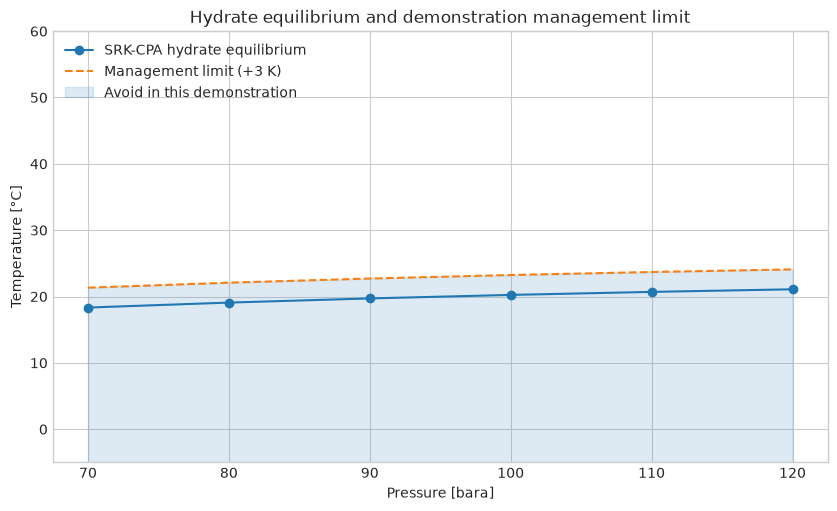

At 95–120 bara, the equilibrium curve spans **19.7–21.1 °C**. The calculation will therefore stop counting safe time 3 K above equilibrium, before entering the shaded region.

In [3]:
def build_fluid(temperature_C=CASE["inlet_temperature_C"],
                pressure_bara=CASE["inlet_pressure_bara"],
                flow_kg_s=CASE["mass_rate_kg_s"]):
    fluid = SystemSrkCPA(temperature_C + 273.15, pressure_bara)
    for name, amount in COMPOSITION.items():
        fluid.addComponent(name, float(amount))
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(float(flow_kg_s), "kg/sec")
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    return fluid

feed_fluid = build_fluid()
phase_rows = []
for i in range(feed_fluid.getNumberOfPhases()):
    phase = feed_fluid.getPhase(i)
    phase_rows.append({
        "phase": str(phase.getPhaseTypeName()),
        "moles_fraction": float(phase.getBeta()),
        "density_kg_m3": float(phase.getDensity("kg/m3")),
        "viscosity_mPa_s": 1000.0 * float(phase.getViscosity("kg/msec")),
    })
phase_table = pd.DataFrame(phase_rows)
display(phase_table.round(5))
phase_names = {name.lower() for name in phase_table["phase"]}
assert {"gas", "oil", "aqueous"}.issubset(phase_names), phase_names

hydrate_cache = {}
def hydrate_temperature_C(pressure_bara):
    key = round(float(pressure_bara), 4)
    if key not in hydrate_cache:
        fluid = SystemSrkCPA(283.15, key)
        for name, amount in COMPOSITION.items():
            fluid.addComponent(name, float(amount))
        fluid.setMixingRule(10)
        fluid.setHydrateCheck(True)
        ThermodynamicOperations(fluid).hydrateFormationTemperature()
        hydrate_cache[key] = float(fluid.getTemperature("C"))
    return hydrate_cache[key]

hydrate_pressure_bara = np.arange(70.0, 121.0, 10.0)
hydrate_temperature_curve_C = np.array(
    [hydrate_temperature_C(p) for p in hydrate_pressure_bara]
)
hydrate_table = pd.DataFrame({
    "pressure_bara": hydrate_pressure_bara,
    "hydrate_equilibrium_C": hydrate_temperature_curve_C,
    "management_limit_C": hydrate_temperature_curve_C + CASE["hydrate_safety_margin_K"],
})
display(hydrate_table.round(3))

fig, ax = plt.subplots()
ax.plot(hydrate_pressure_bara, hydrate_temperature_curve_C, "o-", label="SRK-CPA hydrate equilibrium")
ax.plot(hydrate_pressure_bara, hydrate_temperature_curve_C + CASE["hydrate_safety_margin_K"],
        "--", label="Management limit (+3 K)")
ax.fill_between(hydrate_pressure_bara, -5.0,
                hydrate_temperature_curve_C + CASE["hydrate_safety_margin_K"],
                alpha=0.15, color="tab:blue", label="Avoid in this demonstration")
ax.set(xlabel="Pressure [bara]", ylabel="Temperature [°C]", ylim=(-5, 60),
       title="Hydrate equilibrium and demonstration management limit")
ax.legend(loc="upper left")
plt.show()
display(Markdown(
    f"At 95–120 bara, the equilibrium curve spans **{hydrate_temperature_curve_C[2]:.1f}–"
    f"{hydrate_temperature_curve_C[-1]:.1f} °C**. The calculation will therefore stop counting safe time "
    "3 K above equilibrium, before entering the shaded region."
))

## 4. Flowing two-fluid initialization

The six finite-volume cells are intentionally coarse enough to keep the demonstration quick while retaining terrain-induced inventory differences. A 25 kg/s wellstream enters at 55 °C and 120 bara; the outlet pressure is fixed at 95 bara. A simple flowing U-value initializes the axial thermal state. Shutdown then replaces this with the radial steel/FBE/PU-foam thermal model.

,x_km,elevation_m,pressure_bara,temperature_C,gas_holdup,oil_holdup,water_holdup,hydrate_equilibrium_C,hydrate_margin_K
0,1.0,0.0,97.3532,55.0000,0.0500,0.9329,0.0171,20.1008,31.8992
1,3.0,-20.0,98.6886,54.1117,0.5068,0.4835,0.0097,20.1716,30.9400
2,5.0,-50.0,97.4621,53.2388,0.1500,0.8280,0.0220,20.1066,30.1322
3,7.0,-30.0,96.4276,52.3812,0.5114,0.4749,0.0137,20.0518,29.3294
4,9.0,-10.0,95.8646,51.5384,0.5100,0.4750,0.0150,20.0219,28.5165
5,11.0,0.0,95.0000,50.7104,0.5109,0.4729,0.0162,19.9761,27.7343


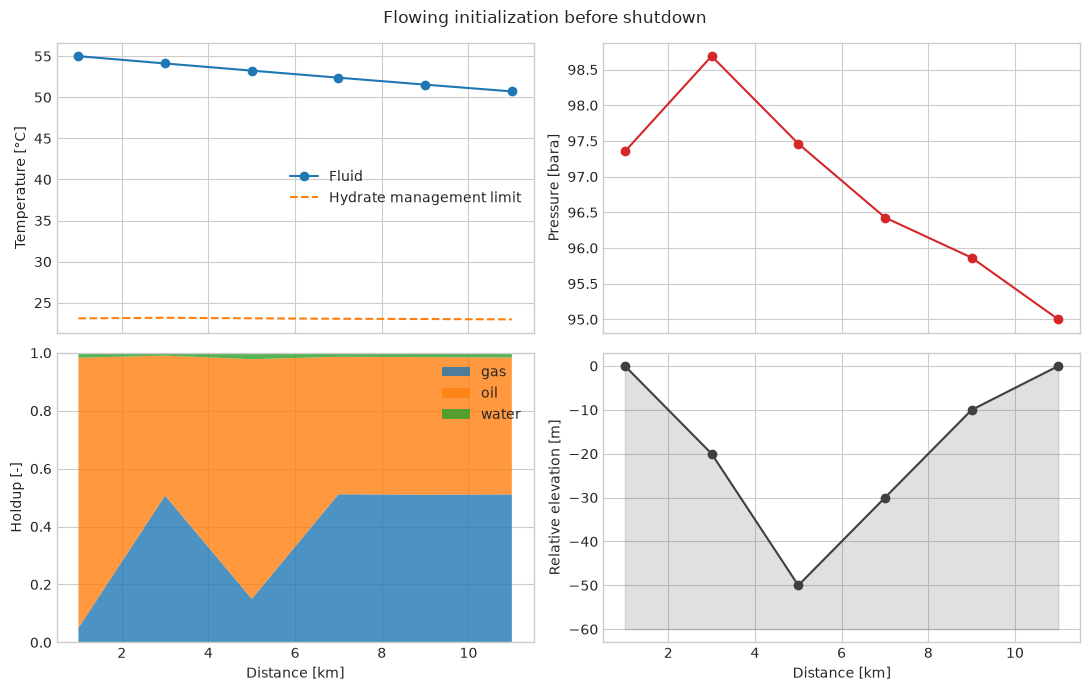

The flowing state cools from **55.0 to 50.7 °C**. Its minimum management margin is **27.7 K**. The terrain and holdup panels identify why the first unsafe point need not be the outlet.

In [4]:
def build_flowing_pipe():
    inlet = Stream("three-phase wellstream", build_fluid())
    inlet.setFlowRate(CASE["mass_rate_kg_s"], "kg/sec")
    inlet.setTemperature(CASE["inlet_temperature_C"], "C")
    inlet.setPressure(CASE["inlet_pressure_bara"], "bara")
    inlet.run()

    pipe = TwoFluidPipe("12 km shutdown cooldown demonstration", inlet)
    pipe.setLength(CASE["length_m"])
    pipe.setDiameter(CASE["diameter_m"])
    pipe.setRoughness(CASE["roughness_m"])
    pipe.setNumberOfSections(CASE["sections"])
    pipe.setElevationProfile(JArray(JDouble)(CASE["elevation_m"]))
    pipe.setEnableTerrainTracking(True)
    pipe.setOutletPressure(CASE["outlet_pressure_bara"], "bara")
    pipe.setIncludeEnergyEquation(True)
    pipe.setSurfaceTemperature(CASE["ambient_C"], "C")
    pipe.setHeatTransferCoefficient(CASE["flowing_U_W_m2K"])
    pipe.setThermodynamicUpdateInterval(8)
    pipe.setSteadyStateFlashInterval(8)
    pipe.setSteadyStateMaxWallClockTime(90.0)
    pipe.run()
    return inlet, pipe

steady_started = time.monotonic()
steady_inlet, steady_pipe = build_flowing_pipe()
steady_elapsed_s = time.monotonic() - steady_started

x_m = np.asarray(steady_pipe.getPositionProfile(), dtype=float)
steady = pd.DataFrame({
    "x_km": x_m / 1000.0,
    "elevation_m": CASE["elevation_m"],
    "pressure_bara": np.asarray(steady_pipe.getPressureProfile(), dtype=float) / 1e5,
    "temperature_C": np.asarray(steady_pipe.getTemperatureProfile("C"), dtype=float),
    "gas_holdup": 1.0 - np.asarray(steady_pipe.getLiquidHoldupProfile(), dtype=float),
    "oil_holdup": np.asarray(steady_pipe.getOilHoldupProfile(), dtype=float),
    "water_holdup": np.asarray(steady_pipe.getWaterHoldupProfile(), dtype=float),
})
steady["hydrate_equilibrium_C"] = np.interp(
    steady["pressure_bara"], hydrate_pressure_bara, hydrate_temperature_curve_C
)
steady["hydrate_margin_K"] = (
    steady["temperature_C"] - steady["hydrate_equilibrium_C"]
    - CASE["hydrate_safety_margin_K"]
)
display(steady.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axes[0, 0].plot(steady.x_km, steady.temperature_C, "o-", label="Fluid")
axes[0, 0].plot(steady.x_km, steady.hydrate_equilibrium_C + CASE["hydrate_safety_margin_K"],
                "--", label="Hydrate management limit")
axes[0, 0].set_ylabel("Temperature [°C]"); axes[0, 0].legend()
axes[0, 1].plot(steady.x_km, steady.pressure_bara, "o-", color="tab:red")
axes[0, 1].set_ylabel("Pressure [bara]")
axes[1, 0].stackplot(steady.x_km, steady.gas_holdup, steady.oil_holdup, steady.water_holdup,
                     labels=["gas", "oil", "water"], alpha=0.8)
axes[1, 0].set(xlabel="Distance [km]", ylabel="Holdup [-]", ylim=(0, 1)); axes[1, 0].legend(loc="upper right")
axes[1, 1].plot(steady.x_km, steady.elevation_m, "o-", color="0.25")
axes[1, 1].fill_between(steady.x_km, steady.elevation_m, min(steady.elevation_m)-10, alpha=0.2, color="0.4")
axes[1, 1].set(xlabel="Distance [km]", ylabel="Relative elevation [m]")
fig.suptitle("Flowing initialization before shutdown")
fig.tight_layout()
plt.show()
display(Markdown(
    f"The flowing state cools from **{steady.temperature_C.iloc[0]:.1f} to {steady.temperature_C.iloc[-1]:.1f} °C**. "
    f"Its minimum management margin is **{steady.hydrate_margin_K.min():.1f} K**. "
    "The terrain and holdup panels identify why the first unsafe point need not be the outlet."
))

## 5. Close-in transient with radial thermal inertia

Both external mass-flow faces are closed. NeqSim retains local gas, oil, and water inventories, updates the three-phase two-fluid state, and exchanges heat in every cell with cell-owned radial layer temperatures. The closed-flow fluid-side coefficient is set explicitly to 50 W/(m² K); the radial calculator separately represents steel, FBE, and 60 mm PU foam. This avoids treating the insulation-level overall U-value as a second fluid-film coefficient.

The base run uses 15-minute macro steps for 18 hours. Hydrate equilibrium is interpolated from the SRK-CPA pressure grid at every cell and time step.

In [5]:
def configure_shutdown(pipe):
    pipe.setWallProperties(CASE["wall_thickness_m"], 7850.0, 480.0)
    pipe.setSurfaceTemperature(CASE["ambient_C"], "C")
    pipe.configureSubseaThermalModel(
        CASE["insulation_thickness_m"], 0.0, MaterialType.PU_FOAM
    )
    calculator = pipe.getThermalCalculator()
    calculator.setFluidTemperature(float(np.mean(pipe.getTemperatureProfile())))
    calculator.setAmbientTemperature(CASE["ambient_C"] + 273.15)
    calculator.initializeLayerTemperaturesLinear()
    radial_overall_U = float(calculator.calculateOverallUValue())
    pipe.setHeatTransferCoefficient(CASE["closed_inner_htc_W_m2K"])
    pipe.setIncludeMassTransfer(False)
    pipe.setComponentTransportEnabled(False)
    pipe.setEnableJouleThomson(False)
    pipe.setEnableAdaptiveTimestepping(False)
    pipe.setThermodynamicUpdateInterval(1_000_000)
    pipe.closeInlet()
    pipe.closeOutlet()
    return radial_overall_U

def local_record(pipe, time_s, mass0_kg):
    p_bara = np.asarray(pipe.getPressureProfile(), dtype=float) / 1e5
    T_C = np.asarray(pipe.getTemperatureProfile("C"), dtype=float)
    alpha_o = np.asarray(pipe.getOilHoldupProfile(), dtype=float)
    alpha_w = np.asarray(pipe.getWaterHoldupProfile(), dtype=float)
    alpha_g = 1.0 - np.asarray(pipe.getLiquidHoldupProfile(), dtype=float)
    T_hyd_C = np.interp(p_bara, hydrate_pressure_bara, hydrate_temperature_curve_C)
    margin_K = T_C - T_hyd_C - CASE["hydrate_safety_margin_K"]
    mass_report = pipe.getLastMassBalanceReport() if time_s > 0 else None
    thermal_report = pipe.getLastThermalEnergyBalanceReport() if time_s > 0 else None
    rows = []
    for i in range(CASE["sections"]):
        rows.append({
            "time_s": time_s, "time_h": time_s / 3600.0, "cell": i,
            "x_m": x_m[i], "elevation_m": CASE["elevation_m"][i],
            "pressure_Pa": p_bara[i] * 1e5, "pressure_bara": p_bara[i],
            "temperature_K": T_C[i] + 273.15, "temperature_C": T_C[i],
            "wall_temperature_K": float(np.asarray(pipe.getWallTemperatureProfile(), dtype=float)[i]) if time_s > 0 else np.nan,
            "alpha_gas": alpha_g[i], "alpha_oil": alpha_o[i], "alpha_water": alpha_w[i],
            "gas_velocity_m_s": float(np.asarray(pipe.getGasVelocityProfile(), dtype=float)[i]),
            "oil_velocity_m_s": float(np.asarray(pipe.getOilVelocityProfile(), dtype=float)[i]),
            "water_velocity_m_s": float(np.asarray(pipe.getWaterVelocityProfile(), dtype=float)[i]),
            "hydrate_equilibrium_T_K": T_hyd_C[i] + 273.15,
            "hydrate_margin_K": margin_K[i],
            "total_mass_kg": float(pipe.getTotalMassInventory()),
            "relative_mass_drift": (float(pipe.getTotalMassInventory()) - mass0_kg) / mass0_kg,
            "mass_balance_relative_residual": (
                float(mass_report.getRelativeResidual(MassPhase.TOTAL)) if mass_report else np.nan
            ),
            "thermal_energy_relative_residual": (
                float(thermal_report.getRelativeResidual()) if thermal_report else np.nan
            ),
            "mean_ambient_heat_loss_W_m": (
                float(thermal_report.getAmbientHeatLossJ())
                / float(thermal_report.getElapsedTimeSeconds()) / CASE["length_m"]
                if thermal_report else np.nan
            ),
        })
    return rows

def first_crossing_hours(summary):
    values = summary["min_hydrate_margin_K"].to_numpy()
    indices = np.flatnonzero(values <= 0.0)
    if len(indices) == 0:
        return np.nan
    k = int(indices[0])
    if k == 0:
        return float(summary.time_h.iloc[0])
    t0, t1 = summary.time_h.iloc[k-1], summary.time_h.iloc[k]
    y0, y1 = values[k-1], values[k]
    return float(t0 + (0.0 - y0) * (t1 - t0) / (y1 - y0))

def run_shutdown(dt_s):
    _, pipe = build_flowing_pipe()
    radial_U = configure_shutdown(pipe)
    mass0_kg = float(pipe.getTotalMassInventory())
    records = local_record(pipe, 0.0, mass0_kg)
    steps = int(round(CASE["horizon_h"] * 3600.0 / dt_s))
    for step in range(1, steps + 1):
        pipe.runTransient(float(dt_s))
        records.extend(local_record(pipe, step * dt_s, mass0_kg))
    history = pd.DataFrame(records)
    summary = history.groupby("time_h", as_index=False).agg(
        minimum_temperature_C=("temperature_C", "min"),
        mean_temperature_C=("temperature_C", "mean"),
        maximum_temperature_C=("temperature_C", "max"),
        min_hydrate_margin_K=("hydrate_margin_K", "min"),
        max_abs_mass_drift=("relative_mass_drift", lambda x: np.max(np.abs(x))),
        max_mass_residual=("mass_balance_relative_residual", lambda x: np.nanmax(np.abs(x)) if np.any(np.isfinite(x)) else np.nan),
        max_energy_residual=("thermal_energy_relative_residual", lambda x: np.nanmax(np.abs(x)) if np.any(np.isfinite(x)) else np.nan),
    )
    return pipe, history, summary, first_crossing_hours(summary), radial_U

cooldown_started = time.monotonic()
fine_pipe, fine_history, fine_summary, no_touch_h, radial_overall_U = run_shutdown(CASE["fine_dt_s"])
fine_elapsed_s = time.monotonic() - cooldown_started
display(fine_summary.iloc[::8].round(5))
print(f"Interpolated no-touch time: {no_touch_h:.3f} h")
print(f"Radial configuration overall U (inner-area basis): {radial_overall_U:.3f} W/(m² K)")

Interpolated no-touch time: 14.139 h
Radial configuration overall U (inner-area basis): 0.777 W/(m² K)


,time_h,minimum_temperature_C,mean_temperature_C,maximum_temperature_C,min_hydrate_margin_K,max_abs_mass_drift,max_mass_residual,max_energy_residual
0,0.0,50.71040,52.83008,55.00000,27.73433,0.0,NaN,NaN
8,2.0,44.97336,46.80321,48.19355,21.80171,0.0,0.0,0.0
16,4.0,39.39463,41.79381,43.40504,16.22299,0.0,0.0,0.0
24,6.0,35.30221,37.48207,39.00940,12.13057,0.0,0.0,0.0
32,8.0,31.69254,33.68662,35.05482,8.52090,0.0,0.0,0.0
40,10.0,28.56017,30.33448,31.55232,5.38853,0.0,0.0,0.0
48,12.0,25.80422,27.36139,28.43844,2.63258,0.0,0.0,0.0
56,14.0,23.36827,24.73322,25.67694,0.19663,0.0,0.0,0.0
64,16.0,21.13667,22.37810,23.22667,-2.03497,0.0,0.0,0.0
72,18.0,19.21319,20.31024,21.05012,-3.95845,0.0,0.0,0.0


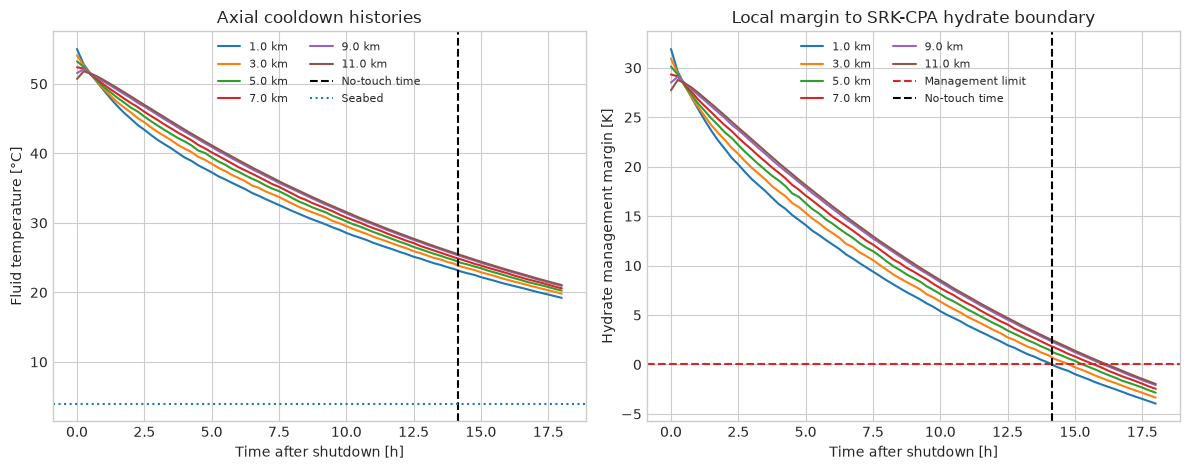

The first zero-margin crossing occurs at **14.14 h**, near **1.0 km**. At the nearest stored time, that cell is **23.0 °C** at **98.7 bara**. This axial minimum—not the mean flowline temperature—is the operational decision point.

In [6]:
coldest = fine_history.loc[fine_history.groupby("time_h")["hydrate_margin_K"].idxmin()].copy()
critical_row = coldest.iloc[np.argmin(np.abs(coldest.time_h - no_touch_h))]
critical_cell = int(critical_row.cell)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for cell in range(CASE["sections"]):
    part = fine_history[fine_history.cell == cell]
    axes[0].plot(part.time_h, part.temperature_C, label=f"{x_m[cell]/1000:.1f} km")
    axes[1].plot(part.time_h, part.hydrate_margin_K, label=f"{x_m[cell]/1000:.1f} km")
axes[0].axvline(no_touch_h, color="k", linestyle="--", label="No-touch time")
axes[0].axhline(CASE["ambient_C"], color="tab:blue", linestyle=":", label="Seabed")
axes[0].set(xlabel="Time after shutdown [h]", ylabel="Fluid temperature [°C]",
            title="Axial cooldown histories")
axes[1].axhline(0.0, color="tab:red", linestyle="--", label="Management limit")
axes[1].axvline(no_touch_h, color="k", linestyle="--", label="No-touch time")
axes[1].set(xlabel="Time after shutdown [h]", ylabel="Hydrate management margin [K]",
            title="Local margin to SRK-CPA hydrate boundary")
axes[0].legend(ncol=2, fontsize=8); axes[1].legend(ncol=2, fontsize=8)
fig.tight_layout(); plt.show()

display(Markdown(
    f"The first zero-margin crossing occurs at **{no_touch_h:.2f} h**, near **{critical_row.x_m/1000:.1f} km**. "
    f"At the nearest stored time, that cell is **{critical_row.temperature_C:.1f} °C** at "
    f"**{critical_row.pressure_bara:.1f} bara**. This axial minimum—not the mean flowline temperature—is the "
    "operational decision point."
))

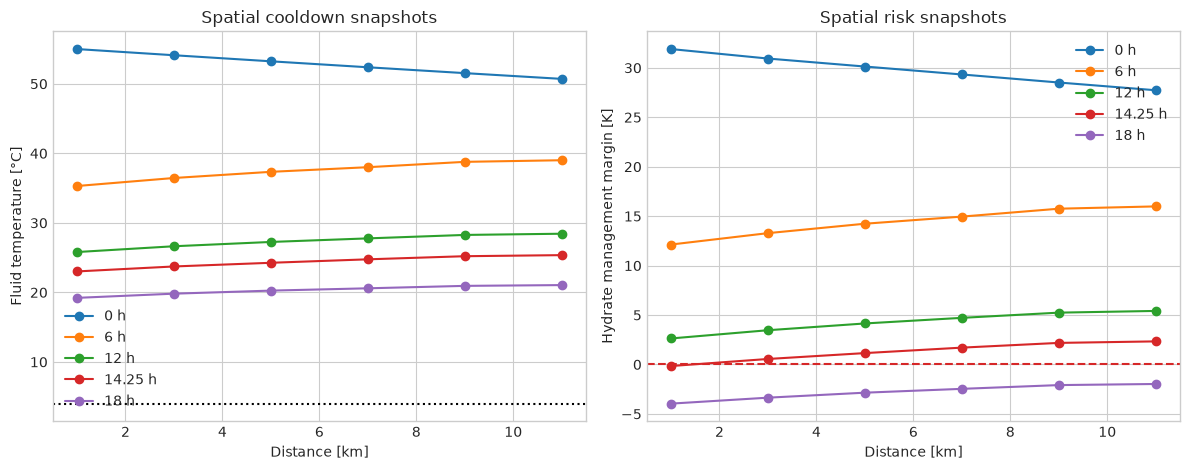

,time_h,x_m,pressure_bara,temperature_C,hydrate_equilibrium_T_K,hydrate_margin_K
342,14.25,1000.0,98.6886,23.015,293.3216,-0.1566


The profiles remain axially non-uniform after close-in because each cell starts with different temperature and phase inventory. The 12 h curve still has positive margin; the curve nearest the interpolated crossing first touches zero at the identified cell.

In [7]:
snapshot_hours = [0.0, 6.0, 12.0, round(no_touch_h / 0.25) * 0.25, 18.0]
snapshot_hours = sorted(set(float(v) for v in snapshot_hours))
snapshots = fine_history[fine_history.time_h.isin(snapshot_hours)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for hour in snapshot_hours:
    part = snapshots[snapshots.time_h == hour]
    axes[0].plot(part.x_m / 1000, part.temperature_C, "o-", label=f"{hour:g} h")
    axes[1].plot(part.x_m / 1000, part.hydrate_margin_K, "o-", label=f"{hour:g} h")
axes[0].axhline(CASE["ambient_C"], color="k", linestyle=":")
axes[0].set(xlabel="Distance [km]", ylabel="Fluid temperature [°C]", title="Spatial cooldown snapshots")
axes[1].axhline(0.0, color="tab:red", linestyle="--")
axes[1].set(xlabel="Distance [km]", ylabel="Hydrate management margin [K]", title="Spatial risk snapshots")
axes[0].legend(); axes[1].legend(); fig.tight_layout(); plt.show()

first_unsafe = fine_history[fine_history.hydrate_margin_K <= 0].sort_values(["time_h", "hydrate_margin_K"]).head(1)
display(first_unsafe[["time_h", "x_m", "pressure_bara", "temperature_C", "hydrate_equilibrium_T_K", "hydrate_margin_K"]].round(4))
display(Markdown(
    "The profiles remain axially non-uniform after close-in because each cell starts with different temperature and "
    "phase inventory. The 12 h curve still has positive margin; the curve nearest the interpolated crossing first "
    "touches zero at the identified cell."
))

## 6. Verification and independent screening

The two-fluid answer is checked against a 30-minute run from a freshly initialized flowing state and the native `SurfCooldownAnalyzer`. The latter is intentionally only a lumped screen: it cannot see terrain, axial gradients, phase redistribution, or local wall states. Agreement in order of magnitude is expected; identity is not.

In [8]:
coarse_started = time.monotonic()
coarse_pipe, coarse_history, coarse_summary, coarse_no_touch_h, _ = run_shutdown(CASE["coarse_dt_s"])
coarse_elapsed_s = time.monotonic() - coarse_started

lumped_fluid = build_fluid(
    temperature_C=float(steady.temperature_C.mean()),
    pressure_bara=float(steady.pressure_bara.mean()),
)
lumped = SurfCooldownAnalyzer(lumped_fluid)
lumped.setInternalDiameter(CASE["diameter_m"])
lumped.setWallThickness(CASE["wall_thickness_m"])
lumped.setInsulationThickness(CASE["insulation_thickness_m"])
lumped.setInsulationConductivity(0.035)
lumped.setCoatingThickness(0.0005)
lumped.setSeabedTemperature(CASE["ambient_C"])
lumped.setOperatingTemperature(float(steady.temperature_C.mean()))
lumped.setHydrateMargin(CASE["hydrate_safety_margin_K"])
lumped.setRequiredNoTouchTimeHours(12.0)
lumped.setTimeStepMinutes(5.0)
lumped.setTotalTimeHours(120.0)
lumped.calculate()
lumped_no_touch_h = float(lumped.getNoTouchTimeHours())

dt_difference_percent = 100.0 * abs(no_touch_h - coarse_no_touch_h) / no_touch_h
mass_drift = float(fine_summary.max_abs_mass_drift.max())
mass_residual = float(fine_summary.max_mass_residual.max())
energy_residual = float(fine_summary.max_energy_residual.max())
largest_upward_minimum_step_C = float(np.max(np.diff(fine_summary.minimum_temperature_C)))
net_mean_cooldown_C = float(
    fine_summary.mean_temperature_C.iloc[0] - fine_summary.mean_temperature_C.iloc[-1]
)
alpha_sum_error = float(np.max(np.abs(
    fine_history[["alpha_gas", "alpha_oil", "alpha_water"]].sum(axis=1) - 1.0
)))

checks = pd.DataFrame([
    ("Three thermodynamic phases", ", ".join(sorted(phase_names)), "gas, oil, aqueous", True),
    ("Fine-step no-touch time", no_touch_h, "8–24 h demonstration range", 8 < no_touch_h < 24),
    ("30 min vs 15 min difference [%]", dt_difference_percent, "< 5", dt_difference_percent < 5),
    ("Maximum relative inventory drift", mass_drift, "< 1e-8", mass_drift < 1e-8),
    ("Maximum mass-balance residual", mass_residual, "< 1e-8", mass_residual < 1e-8),
    ("Maximum thermal-energy residual", energy_residual, "< 1e-8", energy_residual < 1e-8),
    ("Maximum phase-fraction sum error", alpha_sum_error, "< 1e-10", alpha_sum_error < 1e-10),
    ("Net mean cooldown [°C]", net_mean_cooldown_C, "> 15", net_mean_cooldown_C > 15.0),
    ("Minimum fluid temperature [°C]", fine_history.temperature_C.min(), "> seabed − 0.1", fine_history.temperature_C.min() > CASE["ambient_C"] - 0.1),
])
checks.columns = ["check", "value", "limit", "passed"]
display(checks)
assert bool(checks.passed.all()), checks[~checks.passed]
print(
    "Largest one-step rise of the local minimum was "
    f"{largest_upward_minimum_step_C:.3f} °C during closed-pipe pressure/holdup redistribution."
)

comparison = pd.DataFrame({
    "model": ["TwoFluidPipe, 15 min", "TwoFluidPipe, 30 min", "SurfCooldownAnalyzer, lumped"],
    "no_touch_time_h": [no_touch_h, coarse_no_touch_h, lumped_no_touch_h],
    "resolves_axial_state": [True, True, False],
    "resolves_phase_holdup": [True, True, False],
})
display(comparison.round(3))
display(Markdown(
    f"Halving the macro step changes no-touch time by **{dt_difference_percent:.2f}%**. "
    f"The native lumped screen gives **{lumped_no_touch_h:.2f} h** versus **{no_touch_h:.2f} h** for the "
    "axially resolved two-fluid calculation. Conservation gates pass; the numerical result is stable enough for this demonstration."
))

Largest one-step rise of the local minimum was 1.086 °C during closed-pipe pressure/holdup redistribution.


,check,value,limit,passed
0,Three thermodynamic phases,"aqueous, gas, oil","gas, oil, aqueous",True
1,Fine-step no-touch time,14.139157,8–24 h demonstration range,True
2,30 min vs 15 min difference [%],0.078258,< 5,True
3,Maximum relative inventory drift,0.0,< 1e-8,True
4,Maximum mass-balance residual,0.0,< 1e-8,True
5,Maximum thermal-energy residual,0.0,< 1e-8,True
6,Maximum phase-fraction sum error,0.0,< 1e-10,True
7,Net mean cooldown [°C],32.519831,> 15,True
8,Minimum fluid temperature [°C],19.213194,> seabed − 0.1,True


,model,no_touch_time_h,resolves_axial_state,resolves_phase_holdup
0,"TwoFluidPipe, 15 min",14.139,True,True
1,"TwoFluidPipe, 30 min",14.150,True,True
2,"SurfCooldownAnalyzer, lumped",59.695,False,False


Halving the macro step changes no-touch time by **0.08%**. The native lumped screen gives **59.70 h** versus **14.14 h** for the axially resolved two-fluid calculation. Conservation gates pass; the numerical result is stable enough for this demonstration.

## 7. One-way NeqSim → OpenFOAM dead-leg handoff

The tee is placed at the synthetic low point near 4.8 km. The export contains SI-unit time histories at that parent-pipe cell, the complete shutdown initial profile, a flashed phase-property table at the tee, and a manifest with model identity and boundary semantics.

| Quantity | NeqSim source | Suggested CFD use |
|---|---|---|
| $P(t)$ | local two-fluid cell pressure | reference/pressure boundary and density state |
| $T(t)$ | local bulk fluid temperature | parent-pipe inflow or time-varying mixed boundary |
| $\alpha_g,\alpha_o,\alpha_w$ | local phase holdups | phase-fraction boundary/initial condition |
| velocity | final flowing two-fluid state | initialize the CFD velocity field at $t=0$ only |
| $T_{hyd}(t),M(t)$ | SRK-CPA post-processing | CFD cold-spot risk field and reporting threshold |
| phase properties | tee-state SRK-CPA flash | OpenFOAM thermophysical dictionaries or tabulation |

Start with **offline one-way coupling**. Include a short parent-pipe length on both sides of the tee so that the CFD solution develops a physically meaningful exchange flow. Map pressure, temperature, and phase fraction from the two adjacent NeqSim cells onto those two CFD patches. After closure, use pressure-driven/zero-gradient velocity boundaries rather than imposing the coarse one-dimensional cell velocities. If the circumferentially integrated CFD wall heat loss differs materially from the one-dimensional assumption, reduce it to $q'(x,t)$ in W/m and iterate it back through a NeqSim heat-transfer profile. That is the clean path toward partitioned two-way coupling; direct simultaneous co-simulation is unnecessary for the first study.

Packaged CFD handoff: /tmp/openfoam_deadleg_handoff.zip (20,463 bytes)


,patch_name,source_cell,source_x_m,time_s,pressure_Pa,temperature_K,alpha_gas,alpha_oil,alpha_water,hydrate_equilibrium_T_K,hydrate_margin_K
0,parent_upstream,1,3000.0,0.0,9.868856e+06,327.261667,0.506830,0.483504,0.009665,293.321641,30.940026
1,parent_upstream,1,3000.0,900.0,9.868856e+06,325.748762,0.454587,0.532125,0.013288,293.321641,29.427121
2,parent_upstream,1,3000.0,1800.0,9.868856e+06,324.532921,0.459902,0.520101,0.019998,293.321641,28.211280
73,parent_downstream,3,7000.0,0.0,9.642758e+06,325.531151,0.511407,0.474866,0.013726,293.201762,29.329390
74,parent_downstream,3,7000.0,900.0,9.642758e+06,325.351058,0.050000,0.918140,0.031860,293.201762,29.149296
75,parent_downstream,3,7000.0,1800.0,9.642758e+06,324.539738,0.050000,0.913862,0.036138,293.201762,28.337976


,phase,density_kg_m3,dynamic_viscosity_Pa_s,specific_heat_J_kgK,thermal_conductivity_W_mK
0,gas,97.127386,0.000016,2891.120677,0.044674
1,oil,513.051020,0.000113,2614.877857,0.090740
2,aqueous,988.298963,0.000519,3820.035083,0.649411


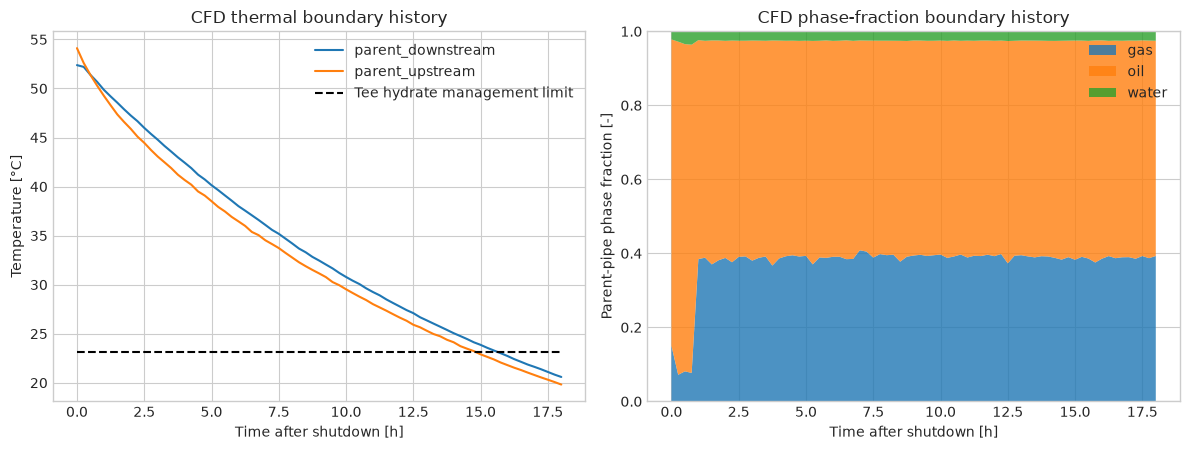

The export uses cell **2 at 5.0 km**, the terrain low point. Row zero preserves the final flowing boundary; later rows describe the closed-parent-pipe state. A local CFD model can now test whether the dead leg becomes colder than the 1D parent cell.

In [9]:
tee_cell = int(np.argmin(np.asarray(CASE["elevation_m"], dtype=float)))
tee_history = fine_history[fine_history.cell == tee_cell].copy()
upstream_cell = max(0, tee_cell - 1)
downstream_cell = min(CASE["sections"] - 1, tee_cell + 1)
boundary_columns = [
    "time_s", "pressure_Pa", "temperature_K", "alpha_gas", "alpha_oil", "alpha_water",
    "hydrate_equilibrium_T_K", "hydrate_margin_K",
]
boundary_frames = []
for patch_name, source_cell in (("parent_upstream", upstream_cell), ("parent_downstream", downstream_cell)):
    frame = fine_history[fine_history.cell == source_cell][boundary_columns].copy()
    frame.insert(0, "source_x_m", float(x_m[source_cell]))
    frame.insert(0, "source_cell", source_cell)
    frame.insert(0, "patch_name", patch_name)
    boundary_frames.append(frame)
boundary = pd.concat(boundary_frames, ignore_index=True)

tee_initial = tee_history.iloc[0]
property_state = build_fluid(
    temperature_C=float(tee_initial.temperature_C),
    pressure_bara=float(tee_initial.pressure_bara),
)
property_rows = []
for i in range(property_state.getNumberOfPhases()):
    phase = property_state.getPhase(i)
    property_rows.append({
        "phase": str(phase.getPhaseTypeName()),
        "density_kg_m3": float(phase.getDensity("kg/m3")),
        "dynamic_viscosity_Pa_s": float(phase.getViscosity("kg/msec")),
        "specific_heat_J_kgK": float(phase.getCp("J/kgK")),
        "thermal_conductivity_W_mK": float(phase.getThermalConductivity("W/mK")),
    })
properties = pd.DataFrame(property_rows)

handoff_dir = Path(os.environ.get("NEQSIM_HANDOFF_DIR", "/tmp/openfoam_deadleg_handoff"))
if handoff_dir.exists():
    shutil.rmtree(handoff_dir)
handoff_dir.mkdir(parents=True, exist_ok=True)
boundary.to_csv(handoff_dir / "parent_pipe_boundaries.csv", index=False)
tee_history.to_csv(handoff_dir / "tee_reference_history.csv", index=False)
fine_history[fine_history.time_s == 0].to_csv(handoff_dir / "flowline_initial_fields.csv", index=False)
properties.to_csv(handoff_dir / "tee_phase_properties.csv", index=False)

manifest = {
    "schema_version": 1,
    "purpose": "offline one-way boundary handoff from NeqSim TwoFluidPipe to a local OpenFOAM tee plus dead-leg model",
    "neqsim": provenance,
    "thermodynamic_model": "SystemSrkCPAstatoil; mixing rule 10; multiphase check enabled",
    "composition_relative_amounts": COMPOSITION,
    "flowline_case": CASE,
    "tee": {"cell": tee_cell, "x_m": float(x_m[tee_cell]), "elevation_m": CASE["elevation_m"][tee_cell]},
    "cfd_parent_patches": {
        "parent_upstream": {"source_cell": upstream_cell, "source_x_m": float(x_m[upstream_cell])},
        "parent_downstream": {"source_cell": downstream_cell, "source_x_m": float(x_m[downstream_cell])},
    },
    "time_convention": "seconds after simultaneous inlet and outlet closure; row 0 is the final flowing state",
    "velocity_mapping": "initialize from the t=0 profile; after closure do not prescribe coarse 1D velocities—use mapped pressure with pressure-driven/zero-gradient CFD velocity patches",
    "phase_fraction_convention": "cell volumetric holdup; alpha_gas + alpha_oil + alpha_water = 1",
    "pressure_convention": "absolute pressure in Pa",
    "temperature_convention": "absolute temperature in K",
    "coupling_scope": "system-scale history only; CFD owns local tee/dead-leg flow and conjugate heat transfer",
    "no_touch_time_h": no_touch_h,
}
(handoff_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
(handoff_dir / "README.md").write_text(
    "# NeqSim to OpenFOAM dead-leg handoff\n\n"
    "Map `parent_pipe_boundaries.csv` onto the upstream and downstream parent-pipe CFD patches. "
    "Use `flowline_initial_fields.csv` to initialize the final flowing state, `tee_reference_history.csv` as a "
    "centreline validation history, and "
    "`tee_phase_properties.csv` to initialize or tabulate phase properties. The CFD geometry "
    "should contain a parent-pipe section, tee, solid pipe/insulation, and capped branch. "
    "Interpolate boundary values conservatively in time and preserve the SI units and sign conventions in `manifest.json`.\n",
    encoding="utf-8",
)

zip_path = handoff_dir.with_suffix(".zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(handoff_dir.iterdir()):
        archive.write(path, arcname=path.name)

display(boundary.groupby("patch_name").head(3).round(6))
display(properties.round(6))
print(f"Packaged CFD handoff: {zip_path} ({zip_path.stat().st_size:,} bytes)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for patch_name, part in boundary.groupby("patch_name"):
    axes[0].plot(part.time_s / 3600, part.temperature_K - 273.15, label=patch_name)
axes[0].plot(tee_history.time_s / 3600,
             tee_history.hydrate_equilibrium_T_K - 273.15 + CASE["hydrate_safety_margin_K"],
             "k--", label="Tee hydrate management limit")
axes[0].set(xlabel="Time after shutdown [h]", ylabel="Temperature [°C]", title="CFD thermal boundary history")
axes[0].legend()
axes[1].stackplot(tee_history.time_s / 3600, tee_history.alpha_gas, tee_history.alpha_oil, tee_history.alpha_water,
                  labels=["gas", "oil", "water"], alpha=0.8)
axes[1].set(xlabel="Time after shutdown [h]", ylabel="Parent-pipe phase fraction [-]", ylim=(0, 1),
            title="CFD phase-fraction boundary history")
axes[1].legend(loc="upper right")
fig.tight_layout(); plt.show()
display(Markdown(
    f"The export uses cell **{tee_cell} at {x_m[tee_cell]/1000:.1f} km**, the terrain low point. "
    "Row zero preserves the final flowing boundary; later rows describe the closed-parent-pipe state. "
    "A local CFD model can now test whether the dead leg becomes colder than the 1D parent cell."
))

## 8. Executable OpenFOAM 14 screening model

The handoff is now exercised, not merely exported. The local domain is a **two-dimensional planar screening surrogate**: a 1.5 m parent-pipe slice intersects a 1.5 m capped vertical branch, with separate fluid, steel, and insulation regions. The workflow uses an operator split:

1. OpenFOAM `multiphaseEuler` redistributes the NeqSim gas/oil/water holdups under gravity for one second while checking phase-volume closure.
2. The settled phase fields are frozen. OpenFOAM's multi-region `solid` solver advances effective fluid conduction plus steel and insulation conduction for 96 h. The two parent-pipe ends use the NeqSim temperature histories through 18 h and then hold the final exported value.

This split makes a Colab demonstration tractable and preserves the two checks needed here—local phase placement and conjugate thermal cooldown. It does **not** resolve long-duration natural convection, moving interfaces, phase change, hydrate kinetics, or a circular 3D tee. The official [OpenFOAM 14 release](https://openfoam.org/release/14/) and API documentation for [`multiphaseCoupledTemperature`](https://cpp.openfoam.org/v14/classFoam_1_1multiphaseCoupledTemperatureFvPatchScalarField.html) and [`coupledTemperature`](https://cpp.openfoam.org/v14/classFoam_1_1coupledTemperatureFvPatchScalarField.html) describe the solver and interface conditions used below.

In [10]:
import importlib.util
import shlex

openfoam_override = os.environ.get("OPENFOAM_ROOT_OVERRIDE")
default_openfoam_root = Path("/opt/openfoam14")

if openfoam_override and Path(openfoam_override).is_dir():
    OPENFOAM_ROOT = Path(openfoam_override).resolve()
elif default_openfoam_root.is_dir():
    OPENFOAM_ROOT = default_openfoam_root
else:
    install_openfoam = r'''
set -euo pipefail
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq ca-certificates software-properties-common wget
wget -qO /etc/apt/trusted.gpg.d/openfoam.asc https://dl.openfoam.org/gpg.key
rm -f /etc/apt/sources.list.d/*dl_openfoam_org*list
add-apt-repository -y "http://dl.openfoam.org/ubuntu main dev"
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq --no-install-recommends openfoam14
'''
    subprocess.run(["bash", "-lc", install_openfoam], check=True)
    OPENFOAM_ROOT = default_openfoam_root

foam_multi_run_candidates = list(
    OPENFOAM_ROOT.glob("platforms/*/bin/foamMultiRun")
)
if len(foam_multi_run_candidates) != 1:
    raise RuntimeError("A unique OpenFOAM 14 foamMultiRun binary was not found")
OPENFOAM_PLATFORM = foam_multi_run_candidates[0].parent.parent.name
OPENFOAM_ENV = os.environ.copy()
OPENFOAM_ENV.update({
    "WM_PROJECT_DIR": str(OPENFOAM_ROOT),
    "WM_PROJECT": "OpenFOAM",
    "WM_PROJECT_VERSION": "14",
    "FOAM_ETC": str(OPENFOAM_ROOT / "etc"),
    "FOAM_APPBIN": str(OPENFOAM_ROOT / "platforms" / OPENFOAM_PLATFORM / "bin"),
    "FOAM_LIBBIN": str(OPENFOAM_ROOT / "platforms" / OPENFOAM_PLATFORM / "lib"),
    "FOAM_TUTORIALS": str(OPENFOAM_ROOT / "tutorials"),
})
OPENFOAM_ENV["PATH"] = (
    f"{OPENFOAM_ENV['FOAM_APPBIN']}:{OPENFOAM_ROOT / 'bin'}:"
    + OPENFOAM_ENV.get("PATH", "")
)
library_override = os.environ.get("OPENFOAM_LIBRARY_PATH_OVERRIDE", "")
library_parts = [
    library_override,
    str(OPENFOAM_ROOT / "platforms" / OPENFOAM_PLATFORM / "lib" / "dummy"),
    OPENFOAM_ENV["FOAM_LIBBIN"],
    OPENFOAM_ENV.get("LD_LIBRARY_PATH", ""),
]
OPENFOAM_ENV["LD_LIBRARY_PATH"] = ":".join(
    part for part in library_parts if part
)

foam_help = subprocess.run(
    [str(foam_multi_run_candidates[0]), "-help"],
    env=OPENFOAM_ENV,
    capture_output=True,
    text=True,
    check=True,
)
openfoam_build = next(
    line.split(":", 1)[1].strip()
    for line in foam_help.stdout.splitlines()
    if line.startswith("Build")
)
print(f"OpenFOAM root: {OPENFOAM_ROOT}")
print(f"OpenFOAM platform: {OPENFOAM_PLATFORM}")
print(f"OpenFOAM build: {openfoam_build}")

OpenFOAM root: /tmp/openfoam14-root/opt/openfoam14
OpenFOAM platform: linux64GccDPInt32Opt
OpenFOAM build: 14-7b05503f98a8


## 9. Geometry, property mapping, and case writer

NeqSim owns composition, phase split, pressure history, hydrate equilibrium, and the phase-property snapshot. OpenFOAM owns the local mesh, gravity redistribution, wall/insulation conduction, external convection, and cold-spot field. The table below makes every cross-tool mapping explicit; interfacial tensions, steel/insulation properties, and the external coefficient remain demonstration assumptions.

,quantity,owner/source,OpenFOAM use
0,pressure and T at tee,SRK-CPA / TwoFluidPipe,initial CFD state
1,"T(t), two parent patches",adjacent TwoFluidPipe cells,uniformFixedValue tables
2,gas/oil/water holdup,tee cell at closure,multiphaseEuler initial alpha
3,"rho, mu, Cp, k",tee SRK-CPA flash,constant phase dictionaries
4,hydrate T(t),SRK-CPA,post-processed local risk threshold
5,"steel, PU foam, ambient h",demonstration assumptions,solid regions / externalTemperature


,density_kg_m3,dynamic_viscosity_Pa_s,specific_heat_J_kgK,thermal_conductivity_W_mK
gas,97.127386,0.000016,2891.120677,0.044674
oil,513.051020,0.000113,2614.877857,0.090740
water,988.298963,0.000519,3820.035083,0.649411


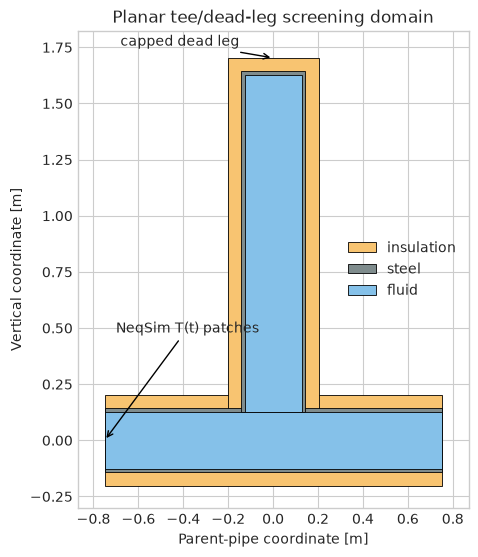

In [11]:
phase_properties_cfd = (
    properties.replace({"phase": {"aqueous": "water"}})
    .set_index("phase")
    .to_dict("index")
)
initial_phase_fraction_cfd = {
    "gas": float(tee_initial.alpha_gas),
    "oil": float(tee_initial.alpha_oil),
    "water": float(tee_initial.alpha_water),
}
CFD_GEOMETRY = {
    "inner_diameter_m": CASE["diameter_m"],
    "wall_thickness_m": CASE["wall_thickness_m"],
    "insulation_thickness_m": CASE["insulation_thickness_m"],
    "parent_half_length_m": 0.75,
    "deadleg_length_m": 1.50,
    "slice_depth_m": 0.010,
}
CFD_CONTROL = {
    "fine_cell_m": 0.035,
    "coarse_cell_m": 0.055,
    "fine_dt_s": 60.0,
    "coarse_dt_s": 120.0,
    "mapped_history_h": CASE["horizon_h"],
    "cfd_horizon_h": 96.0,
    "external_htc_W_m2K": 100.0,
    "steel_conductivity_W_mK": 45.0,
    "insulation_conductivity_W_mK": 0.035,
}

mapping = pd.DataFrame([
    ("pressure and T at tee", "SRK-CPA / TwoFluidPipe", "initial CFD state"),
    ("T(t), two parent patches", "adjacent TwoFluidPipe cells", "uniformFixedValue tables"),
    ("gas/oil/water holdup", "tee cell at closure", "multiphaseEuler initial alpha"),
    ("rho, mu, Cp, k", "tee SRK-CPA flash", "constant phase dictionaries"),
    ("hydrate T(t)", "SRK-CPA", "post-processed local risk threshold"),
    ("steel, PU foam, ambient h", "demonstration assumptions", "solid regions / externalTemperature"),
], columns=["quantity", "owner/source", "OpenFOAM use"])
display(mapping)
display(pd.DataFrame(phase_properties_cfd).T.round(6))

from matplotlib.patches import Rectangle

radius = CFD_GEOMETRY["inner_diameter_m"] / 2
wall = CFD_GEOMETRY["wall_thickness_m"]
insulation = CFD_GEOMETRY["insulation_thickness_m"]
parent_half = CFD_GEOMETRY["parent_half_length_m"]
branch_length = CFD_GEOMETRY["deadleg_length_m"]
fig, ax = plt.subplots(figsize=(9.5, 6.2))
layers = [
    (radius + wall + insulation, radius + wall + insulation, "#f8c471", "insulation"),
    (radius + wall, radius + wall, "#7f8c8d", "steel"),
    (radius, radius, "#85c1e9", "fluid"),
]
for half_width, half_height, color, label in layers:
    ax.add_patch(Rectangle((-parent_half, -half_height), 2*parent_half, 2*half_height,
                           facecolor=color, edgecolor="black", linewidth=0.6, label=label))
    ax.add_patch(Rectangle((-half_width, radius), 2*half_width,
                           branch_length + half_height - radius,
                           facecolor=color, edgecolor="black", linewidth=0.6))
ax.annotate("capped dead leg", (0, radius + branch_length + wall + insulation),
            xytext=(-0.68, radius + branch_length + 0.13), arrowprops={"arrowstyle": "->"})
ax.annotate("NeqSim T(t) patches", (-parent_half, 0), xytext=(-0.70, 0.48),
            arrowprops={"arrowstyle": "->"})
ax.set(xlabel="Parent-pipe coordinate [m]", ylabel="Vertical coordinate [m]",
       title="Planar tee/dead-leg screening domain")
ax.set_xlim(-parent_half - 0.12, parent_half + 0.12)
ax.set_ylim(-(radius + wall + insulation) - 0.10,
            radius + branch_length + wall + insulation + 0.12)
ax.set_aspect("equal"); ax.legend(loc="center right"); plt.show()

In [12]:
import math
import os
from pathlib import Path
import re
import shutil
import subprocess


def _write_case_file(case_dir, relative_path, source):
    path = Path(case_dir) / relative_path
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(source.strip() + "\n", encoding="utf-8")


def run_foam(arguments, case_dir=None, timeout_seconds=900):
    command = [str(value) for value in arguments]
    if case_dir is not None and "-case" not in command:
        command.extend(["-case", str(case_dir)])
    completed = subprocess.run(
        command,
        env=OPENFOAM_ENV,
        capture_output=True,
        text=True,
        timeout=timeout_seconds,
    )
    if completed.returncode != 0:
        print(completed.stdout[-5000:])
        print(completed.stderr[-5000:])
        raise RuntimeError("OpenFOAM command failed: " + " ".join(command))
    return completed


def _inside_rectangle(x, y, x0, x1, y0, y1):
    tolerance = 1.0e-12
    return (
        x0 - tolerance <= x <= x1 + tolerance
        and y0 - tolerance <= y <= y1 + tolerance
    )


def write_deadleg_block_mesh(case_dir, geometry, target_cell_m):
    case_dir = Path(case_dir)
    radius = geometry["inner_diameter_m"] / 2.0
    wall = geometry["wall_thickness_m"]
    insulation = geometry["insulation_thickness_m"]
    parent_half = geometry["parent_half_length_m"]
    branch_length = geometry["deadleg_length_m"]
    half_depth = geometry["slice_depth_m"] / 2.0

    x_coordinates = [
        -parent_half,
        -(radius + wall + insulation),
        -(radius + wall),
        -radius,
        radius,
        radius + wall,
        radius + wall + insulation,
        parent_half,
    ]
    y_coordinates = [
        -(radius + wall + insulation),
        -(radius + wall),
        -radius,
        radius,
        radius + wall,
        radius + wall + insulation,
        radius + branch_length,
        radius + branch_length + wall,
        radius + branch_length + wall + insulation,
    ]

    def material_at(x_value, y_value):
        fluid = (
            _inside_rectangle(
                x_value, y_value,
                -parent_half, parent_half, -radius, radius,
            )
            or _inside_rectangle(
                x_value, y_value,
                -radius, radius, radius, radius + branch_length,
            )
        )
        steel_outer = (
            _inside_rectangle(
                x_value, y_value,
                -parent_half, parent_half,
                -(radius + wall), radius + wall,
            )
            or _inside_rectangle(
                x_value, y_value,
                -(radius + wall), radius + wall,
                radius, radius + branch_length + wall,
            )
        )
        insulation_outer = (
            _inside_rectangle(
                x_value, y_value,
                -parent_half, parent_half,
                -(radius + wall + insulation),
                radius + wall + insulation,
            )
            or _inside_rectangle(
                x_value, y_value,
                -(radius + wall + insulation),
                radius + wall + insulation,
                radius, radius + branch_length + wall + insulation,
            )
        )
        if fluid:
            return "fluid"
        if steel_outer:
            return "steel"
        if insulation_outer:
            return "insulation"
        return None

    vertices = []
    vertex_index = {}

    def vertex(x_value, y_value, z_value):
        key = (x_value, y_value, z_value)
        if key not in vertex_index:
            vertex_index[key] = len(vertices)
            vertices.append(key)
        return vertex_index[key]

    blocks = []
    front_and_back_faces = []
    upstream_faces = []
    downstream_faces = []
    solid_end_faces = []

    for i in range(len(x_coordinates) - 1):
        for j in range(len(y_coordinates) - 1):
            x0, x1 = x_coordinates[i:i + 2]
            y0, y1 = y_coordinates[j:j + 2]
            material = material_at((x0 + x1) / 2.0, (y0 + y1) / 2.0)
            if material is None:
                continue
            indices = (
                vertex(x0, y0, -half_depth),
                vertex(x1, y0, -half_depth),
                vertex(x1, y1, -half_depth),
                vertex(x0, y1, -half_depth),
                vertex(x0, y0, half_depth),
                vertex(x1, y0, half_depth),
                vertex(x1, y1, half_depth),
                vertex(x0, y1, half_depth),
            )
            nx = max(1, round((x1 - x0) / target_cell_m))
            ny = max(1, round((y1 - y0) / target_cell_m))
            blocks.append((indices, material, nx, ny))
            front_and_back_faces.extend(
                [
                    (indices[0], indices[3], indices[2], indices[1]),
                    (indices[4], indices[5], indices[6], indices[7]),
                ]
            )
            if abs(x0 + parent_half) < 1.0e-12:
                face = (indices[0], indices[4], indices[7], indices[3])
                (upstream_faces if material == "fluid" else solid_end_faces).append(face)
            if abs(x1 - parent_half) < 1.0e-12:
                face = (indices[1], indices[2], indices[6], indices[5])
                (downstream_faces if material == "fluid" else solid_end_faces).append(face)

    def face_source(faces):
        return "\n".join(
            "            (" + " ".join(map(str, face)) + ")"
            for face in faces
        )

    block_mesh = f'''FoamFile
{{
    format ascii;
    class dictionary;
    location "system";
    object blockMeshDict;
}}
convertToMeters 1;
vertices
(
{chr(10).join(f"    ({x:.10g} {y:.10g} {z:.10g})" for x, y, z in vertices)}
);
blocks
(
{chr(10).join("    hex (" + " ".join(map(str, ids)) + f") {zone} ({nx} {ny} 1) simpleGrading (1 1 1)" for ids, zone, nx, ny in blocks)}
);
edges ();
faces ();
defaultPatch
{{
    name ambient;
    type wall;
}}
boundary
(
    frontAndBack
    {{
        type empty;
        faces
        (
{face_source(front_and_back_faces)}
        );
    }}
    parentUpstream
    {{
        type wall;
        faces
        (
{face_source(upstream_faces)}
        );
    }}
    parentDownstream
    {{
        type wall;
        faces
        (
{face_source(downstream_faces)}
        );
    }}
    solidEnds
    {{
        type patch;
        faces
        (
{face_source(solid_end_faces)}
        );
    }}
);
mergePatchPairs ();
'''
    _write_case_file(case_dir, "system/blockMeshDict", block_mesh)


def _scalar_field(object_name, dimensions, internal_field, boundary_field):
    return f'''FoamFile
{{
    format ascii;
    class volScalarField;
    location "0/fluid";
    object {object_name};
}}
dimensions {dimensions};
internalField {internal_field};
boundaryField
{{
{boundary_field}
}}
'''


def write_multiphase_settling_case(
    case_dir,
    phase_properties,
    initial_phase_fraction,
    initial_temperature_K,
    initial_pressure_Pa,
    settling_time_s=1.0,
):
    case_dir = Path(case_dir)
    phase_order = ("gas", "oil", "water")

    _write_case_file(case_dir, "system/controlDict", f'''
FoamFile {{ format ascii; class dictionary; location "system"; object controlDict; }}
regionSolvers
{{
    fluid multiphaseEuler;
    steel solid;
    insulation solid;
}}
startFrom startTime;
startTime 0;
stopAt endTime;
endTime {settling_time_s:.10g};
deltaT 1e-4;
writeControl adjustableRunTime;
writeInterval {settling_time_s:.10g};
writeFormat ascii;
writePrecision 10;
writeCompression off;
timeFormat general;
timePrecision 8;
runTimeModifiable true;
adjustTimeStep yes;
maxCo 0.25;
maxAlphaCo 0.25;
maxDeltaT 0.02;
''')
    _write_case_file(case_dir, "system/fvSolution", '''
FoamFile { format ascii; class dictionary; location "system"; object fvSolution; }
PIMPLE { nOuterCorrectors 2; }
''')
    _write_case_file(case_dir, "constant/fluid/g", '''
FoamFile { format ascii; class uniformDimensionedVectorField; location "constant/fluid"; object g; }
dimensions [acceleration];
value (0 -9.81 0);
''')
    _write_case_file(case_dir, "constant/fluid/phaseProperties", '''
FoamFile { format ascii; class dictionary; location "constant/fluid"; object phaseProperties; }
phases (gas oil water);
gas { type purePhaseModel; diameterModel { type constant; d 3e-3; } residualAlpha 1e-6; }
oil { type purePhaseModel; diameterModel { type constant; d 2e-3; } residualAlpha 1e-6; }
water { type purePhaseModel; diameterModel { type constant; d 1e-3; } residualAlpha 1e-6; }
blending { default { type segregated; } }
surfaceTension
{
    gas_oil { type constant; sigma 0.020; }
    gas_water { type constant; sigma 0.055; }
    oil_water { type constant; sigma 0.030; }
}
interfaceCompression { gas_oil 1; gas_water 1; oil_water 1; }
''')
    _write_case_file(case_dir, "constant/fluid/momentumTransfer", '''
FoamFile { format ascii; class dictionary; location "constant/fluid"; object momentumTransfer; }
drag
{
    gas_segregatedWith_oil { type segregated; m 0.1; n 8; }
    gas_segregatedWith_water { $gas_segregatedWith_oil; }
    oil_segregatedWith_water { $gas_segregatedWith_oil; }
}
virtualMass {} lift {} wallLubrication {} turbulentDispersion {}
''')
    _write_case_file(case_dir, "constant/fluid/heatTransfer", '''
FoamFile { format ascii; class dictionary; location "constant/fluid"; object heatTransfer; }
blending
{
    type linear;
    minPartlyContinuousAlpha.gas 0;
    minFullyContinuousAlpha.gas 1;
    minPartlyContinuousAlpha.oil 0;
    minFullyContinuousAlpha.oil 1;
    minPartlyContinuousAlpha.water 0;
    minFullyContinuousAlpha.water 1;
}
gas_dispersedIn_oil { type RanzMarshall; residualAlpha 1e-4; }
oil_dispersedIn_gas { type RanzMarshall; residualAlpha 1e-4; }
gas_dispersedIn_water { type RanzMarshall; residualAlpha 1e-4; }
water_dispersedIn_gas { type RanzMarshall; residualAlpha 1e-4; }
oil_dispersedIn_water { type RanzMarshall; residualAlpha 1e-4; }
water_dispersedIn_oil { type RanzMarshall; residualAlpha 1e-4; }
''')

    molecular_weight = {"gas": 22.0, "oil": 160.0, "water": 18.0}
    for phase in phase_order:
        values = phase_properties[phase]
        prandtl = (
            values["dynamic_viscosity_Pa_s"]
            * values["specific_heat_J_kgK"]
            / values["thermal_conductivity_W_mK"]
        )
        _write_case_file(
            case_dir,
            f"constant/fluid/physicalProperties.{phase}",
            f'''
FoamFile {{ format ascii; class dictionary; location "constant/fluid"; object physicalProperties.{phase}; }}
thermoType
{{
    type heRhoThermo;
    mixture pureMixture;
    transport const;
    thermo hConst;
    equationOfState rhoConst;
    specie specie;
    energy sensibleInternalEnergy;
}}
mixture
{{
    specie {{ molWeight {molecular_weight[phase]:.10g}; }}
    equationOfState {{ rho {values['density_kg_m3']:.12g}; }}
    thermodynamics {{ Cp {values['specific_heat_J_kgK']:.12g}; hf 0; }}
    transport {{ mu {values['dynamic_viscosity_Pa_s']:.12g}; Pr {prandtl:.12g}; }}
}}
''',
        )
        _write_case_file(
            case_dir,
            f"constant/fluid/momentumTransport.{phase}",
            f'''
FoamFile {{ format ascii; class dictionary; location "constant/fluid"; object momentumTransport.{phase}; }}
simulationType laminar;
''',
        )

    _write_case_file(case_dir, "constant/steel/physicalProperties", '''
FoamFile { format ascii; class dictionary; location "constant/steel"; object physicalProperties; }
thermoType constSolidThermo;
rho { type uniform; value 7850; }
Cv { type uniform; value 480; }
kappa { type uniform; value 45; }
''')
    _write_case_file(case_dir, "constant/insulation/physicalProperties", '''
FoamFile { format ascii; class dictionary; location "constant/insulation"; object physicalProperties; }
thermoType constSolidThermo;
rho { type uniform; value 120; }
Cv { type uniform; value 1400; }
kappa { type uniform; value 0.035; }
''')

    _write_case_file(case_dir, "system/fluid/fvSchemes", r'''
FoamFile { format ascii; class dictionary; location "system/fluid"; object fvSchemes; }
ddtSchemes { default Euler; }
gradSchemes { default Gauss linear; }
divSchemes
{
    default none;
    div(phi,alpha) Gauss vanLeer;
    div(phir,alpha,alpha) Gauss vanLeer;
    div(alphaRhoPhi,U) Gauss limitedLinearV 1;
    div(phi,U) Gauss limitedLinearV 1;
    "div\(alphaRhoPhi,(h|e)\)" Gauss limitedLinear 1;
    div(alphaRhoPhi,K) Gauss limitedLinear 1;
    div(alphaRhoPhi,(p|rho)) Gauss limitedLinear 1;
    div((((alpha*rho)*nuEff)*dev2(T(grad(U))))) Gauss linear;
}
laplacianSchemes { default Gauss linear corrected; }
interpolationSchemes { default linear; }
snGradSchemes { default corrected; }
''')
    _write_case_file(case_dir, "system/fluid/fvSolution", r'''
FoamFile { format ascii; class dictionary; location "system/fluid"; object fvSolution; }
solvers
{
    "alpha.*" { nCorrectors 1; nSubCycles 3; }
    p_rgh { solver GAMG; tolerance 1e-7; relTol 0.01; smoother GaussSeidel; }
    p_rghFinal { $p_rgh; relTol 0; }
    "pcorr.*" { solver PCG; preconditioner DIC; tolerance 1e-5; relTol 0; }
    "U.*" { solver smoothSolver; smoother symGaussSeidel; tolerance 1e-6; relTol 0; minIter 1; }
    "e.*" { solver smoothSolver; smoother symGaussSeidel; tolerance 1e-8; relTol 0; }
}
PIMPLE
{
    nCorrectors 2;
    nNonOrthogonalCorrectors 0;
    faceMomentum no;
    VmDdtCorrection no;
    dragCorrection yes;
    pRefCell 0;
    pRefValue 1e7;
}
relaxationFactors { equations { ".*" 1; } }
''')
    _write_case_file(case_dir, "system/fluid/fvConstraints", '''
FoamFile { format ascii; class dictionary; location "system/fluid"; object fvConstraints; }
limitp { type limitPressure; min 1e5; max 2e7; }
''')

    for region in ("steel", "insulation"):
        _write_case_file(case_dir, f"system/{region}/fvSchemes", f'''
FoamFile {{ format ascii; class dictionary; location "system/{region}"; object fvSchemes; }}
ddtSchemes {{ default Euler; }}
gradSchemes {{ default Gauss linear; }}
divSchemes {{ default none; }}
laplacianSchemes {{ default Gauss linear uncorrected; }}
interpolationSchemes {{ default linear; }}
snGradSchemes {{ default uncorrected; }}
''')
        _write_case_file(case_dir, f"system/{region}/fvSolution", f'''
FoamFile {{ format ascii; class dictionary; location "system/{region}"; object fvSolution; }}
solvers
{{
    e {{ solver PCG; preconditioner DIC; tolerance 1e-8; relTol 0; }}
    eFinal {{ $e; relTol 0; }}
}}
PIMPLE {{ nNonOrthogonalCorrectors 0; }}
relaxationFactors {{ equations {{ ".*" 1; }} }}
''')

    alpha_boundary = '''
    frontAndBack { type empty; }
    parentUpstream { type zeroGradient; }
    parentDownstream { type zeroGradient; }
    fluid_to_steel { type zeroGradient; }
'''
    velocity_boundary = '''
    frontAndBack { type empty; }
    parentUpstream { type noSlip; }
    parentDownstream { type noSlip; }
    fluid_to_steel { type noSlip; }
'''
    temperature_boundary = f'''
    frontAndBack {{ type empty; }}
    parentUpstream {{ type fixedValue; value uniform {initial_temperature_K:.12g}; }}
    parentDownstream {{ type fixedValue; value uniform {initial_temperature_K:.12g}; }}
    fluid_to_steel {{ type multiphaseCoupledTemperature; value uniform {initial_temperature_K:.12g}; }}
'''
    pressure_boundary = '''
    frontAndBack { type empty; }
    parentUpstream { type calculated; value $internalField; }
    parentDownstream { type calculated; value $internalField; }
    fluid_to_steel { type calculated; value $internalField; }
'''
    pressure_rgh_boundary = '''
    frontAndBack { type empty; }
    parentUpstream { type fixedFluxPressure; value $internalField; }
    parentDownstream { type fixedFluxPressure; value $internalField; }
    fluid_to_steel { type fixedFluxPressure; value $internalField; }
'''
    for phase in phase_order:
        _write_case_file(
            case_dir,
            f"0/fluid/alpha.{phase}",
            _scalar_field(
                f"alpha.{phase}", "[]",
                f"uniform {initial_phase_fraction[phase]:.12g}",
                alpha_boundary,
            ),
        )
        _write_case_file(case_dir, f"0/fluid/U.{phase}", f'''
FoamFile {{ format ascii; class volVectorField; location "0/fluid"; object U.{phase}; }}
dimensions [velocity];
internalField uniform (0 0 0);
boundaryField {{ {velocity_boundary} }}
''')
        _write_case_file(
            case_dir,
            f"0/fluid/T.{phase}",
            _scalar_field(
                f"T.{phase}", "[temperature]",
                f"uniform {initial_temperature_K:.12g}",
                temperature_boundary,
            ),
        )
    _write_case_file(
        case_dir, "0/fluid/p",
        _scalar_field(
            "p", "[pressure]", f"uniform {initial_pressure_Pa:.12g}",
            pressure_boundary,
        ),
    )
    _write_case_file(
        case_dir, "0/fluid/p_rgh",
        _scalar_field(
            "p_rgh", "[pressure]", f"uniform {initial_pressure_Pa:.12g}",
            pressure_rgh_boundary,
        ),
    )
    _write_case_file(case_dir, "0/steel/T", f'''
FoamFile {{ format ascii; class volScalarField; location "0/steel"; object T; }}
dimensions [temperature];
internalField uniform {initial_temperature_K:.12g};
boundaryField
{{
    frontAndBack {{ type empty; }}
    solidEnds {{ type zeroGradient; }}
    steel_to_insulation {{ type coupledTemperature; value uniform {initial_temperature_K:.12g}; }}
    steel_to_fluid {{ type coupledTemperature; Tnbr T.oil; value uniform {initial_temperature_K:.12g}; }}
}}
''')
    _write_case_file(case_dir, "0/insulation/T", f'''
FoamFile {{ format ascii; class volScalarField; location "0/insulation"; object T; }}
dimensions [temperature];
internalField uniform {initial_temperature_K:.12g};
boundaryField
{{
    frontAndBack {{ type empty; }}
    solidEnds {{ type zeroGradient; }}
    ambient {{ type externalTemperature; Ta constant 277.15; h uniform 100; value uniform {initial_temperature_K:.12g}; }}
    insulation_to_steel {{ type coupledTemperature; value uniform {initial_temperature_K:.12g}; }}
}}
''')


def build_and_settle_case(
    case_dir,
    geometry,
    target_cell_m,
    phase_properties,
    initial_phase_fraction,
    initial_temperature_K,
    initial_pressure_Pa,
):
    case_dir = Path(case_dir)
    if case_dir.exists():
        shutil.rmtree(case_dir)
    case_dir.mkdir(parents=True)
    write_deadleg_block_mesh(case_dir, geometry, target_cell_m)
    write_multiphase_settling_case(
        case_dir,
        phase_properties,
        initial_phase_fraction,
        initial_temperature_K,
        initial_pressure_Pa,
    )
    commands = [
        ("blockMesh", ["blockMesh"]),
        ("splitMeshRegions", ["splitMeshRegions", "-cellZones", "all", "-overwrite"]),
    ]
    logs = {}
    for log_name, command in commands:
        result = run_foam(command, case_dir=case_dir)
        logs[log_name] = result.stdout
        (case_dir / f"log.{log_name}").write_text(result.stdout, encoding="utf-8")
    check_logs = {}
    for region in ("fluid", "steel", "insulation"):
        result = run_foam(["checkMesh", "-region", region], case_dir=case_dir)
        check_logs[region] = result.stdout
        (case_dir / f"log.checkMesh.{region}").write_text(result.stdout, encoding="utf-8")
        if "Mesh OK." not in result.stdout:
            raise RuntimeError(f"OpenFOAM mesh check failed for {region}")
    result = run_foam(["foamMultiRun"], case_dir=case_dir, timeout_seconds=900)
    (case_dir / "log.phaseSettling").write_text(result.stdout, encoding="utf-8")
    if "End" not in result.stdout or "FOAM FATAL" in result.stdout:
        raise RuntimeError("OpenFOAM phase-settling stage did not finish cleanly")
    return {"logs": logs, "check_logs": check_logs, "settling_log": result.stdout}


def _boundary_table(boundary_frame, time_offset_s):
    return "\n".join(
        f"            ({row.time_s + time_offset_s:.10g} {row.temperature_K:.12g})"
        for row in boundary_frame.itertuples()
    )


def write_conjugate_cooldown_case(
    case_dir,
    geometry,
    phase_properties,
    initial_phase_fraction,
    boundary_history,
    initial_temperature_K,
    ambient_temperature_K,
    time_step_s,
    horizon_s,
    start_time_s=1.0,
    write_interval_s=900.0,
):
    case_dir = Path(case_dir)
    rho_effective = sum(
        initial_phase_fraction[phase] * phase_properties[phase]["density_kg_m3"]
        for phase in initial_phase_fraction
    )
    volumetric_heat_capacity = sum(
        initial_phase_fraction[phase]
        * phase_properties[phase]["density_kg_m3"]
        * phase_properties[phase]["specific_heat_J_kgK"]
        for phase in initial_phase_fraction
    )
    cp_effective = volumetric_heat_capacity / rho_effective
    conductivity_effective = sum(
        initial_phase_fraction[phase]
        * phase_properties[phase]["thermal_conductivity_W_mK"]
        for phase in initial_phase_fraction
    )
    end_time_s = start_time_s + horizon_s
    start_name = f"{start_time_s:g}"

    _write_case_file(case_dir, "system/controlDict", f'''
FoamFile {{ format ascii; class dictionary; location "system"; object controlDict; }}
regionSolvers {{ fluid solid; steel solid; insulation solid; }}
startFrom startTime;
startTime {start_time_s:.10g};
stopAt endTime;
endTime {end_time_s:.10g};
deltaT {time_step_s:.10g};
writeControl runTime;
writeInterval {write_interval_s:.10g};
writeFormat ascii;
writePrecision 10;
writeCompression off;
timeFormat general;
timePrecision 8;
runTimeModifiable true;
adjustTimeStep no;
''')
    _write_case_file(case_dir, "constant/fluid/physicalProperties", f'''
FoamFile {{ format ascii; class dictionary; location "constant/fluid"; object physicalProperties; }}
thermoType constSolidThermo;
rho {{ type uniform; value {rho_effective:.12g}; }}
Cv {{ type uniform; value {cp_effective:.12g}; }}
kappa {{ type uniform; value {conductivity_effective:.12g}; }}
''')
    _write_case_file(case_dir, "system/fluid/fvSchemes", '''
FoamFile { format ascii; class dictionary; location "system/fluid"; object fvSchemes; }
ddtSchemes { default Euler; }
gradSchemes { default Gauss linear; }
divSchemes { default none; }
laplacianSchemes { default Gauss linear uncorrected; }
interpolationSchemes { default linear; }
snGradSchemes { default uncorrected; }
''')
    _write_case_file(case_dir, "system/fluid/fvSolution", '''
FoamFile { format ascii; class dictionary; location "system/fluid"; object fvSolution; }
solvers
{
    e { solver PCG; preconditioner DIC; tolerance 1e-8; relTol 0; }
    eFinal { $e; relTol 0; }
}
PIMPLE { nNonOrthogonalCorrectors 0; }
relaxationFactors { equations { ".*" 1; } }
''')
    _write_case_file(case_dir, "system/fluid/fvConstraints", '''
FoamFile { format ascii; class dictionary; location "system/fluid"; object fvConstraints; }
''')

    upstream = boundary_history[
        boundary_history.patch_name == "parent_upstream"
    ].sort_values("time_s")
    downstream = boundary_history[
        boundary_history.patch_name == "parent_downstream"
    ].sort_values("time_s")
    if horizon_s > float(upstream.time_s.iloc[-1]):
        upstream_tail = upstream.iloc[[-1]].copy()
        upstream_tail.loc[:, "time_s"] = horizon_s
        upstream = pd.concat([upstream, upstream_tail], ignore_index=True)
        downstream_tail = downstream.iloc[[-1]].copy()
        downstream_tail.loc[:, "time_s"] = horizon_s
        downstream = pd.concat([downstream, downstream_tail], ignore_index=True)
    upstream_table = _boundary_table(upstream, start_time_s)
    downstream_table = _boundary_table(downstream, start_time_s)

    _write_case_file(case_dir, f"{start_name}/fluid/T", f'''
FoamFile {{ format ascii; class volScalarField; location "{start_name}/fluid"; object T; }}
dimensions [temperature];
internalField uniform {initial_temperature_K:.12g};
boundaryField
{{
    frontAndBack {{ type empty; }}
    parentUpstream
    {{
        type uniformFixedValue;
        uniformValue table
        (
{upstream_table}
        );
        value uniform {float(upstream.temperature_K.iloc[0]):.12g};
    }}
    parentDownstream
    {{
        type uniformFixedValue;
        uniformValue table
        (
{downstream_table}
        );
        value uniform {float(downstream.temperature_K.iloc[0]):.12g};
    }}
    fluid_to_steel {{ type coupledTemperature; value uniform {initial_temperature_K:.12g}; }}
}}
''')
    _write_case_file(case_dir, f"{start_name}/steel/T", f'''
FoamFile {{ format ascii; class volScalarField; location "{start_name}/steel"; object T; }}
dimensions [temperature];
internalField uniform {initial_temperature_K:.12g};
boundaryField
{{
    frontAndBack {{ type empty; }}
    solidEnds {{ type zeroGradient; }}
    steel_to_insulation {{ type coupledTemperature; value uniform {initial_temperature_K:.12g}; }}
    steel_to_fluid {{ type coupledTemperature; value uniform {initial_temperature_K:.12g}; }}
}}
''')
    _write_case_file(case_dir, f"{start_name}/insulation/T", f'''
FoamFile {{ format ascii; class volScalarField; location "{start_name}/insulation"; object T; }}
dimensions [temperature];
internalField uniform {initial_temperature_K:.12g};
boundaryField
{{
    frontAndBack {{ type empty; }}
    solidEnds {{ type zeroGradient; }}
    ambient
    {{
        type externalTemperature;
        Ta constant {ambient_temperature_K:.12g};
        h uniform 100;
        value uniform {initial_temperature_K:.12g};
    }}
    insulation_to_steel {{ type coupledTemperature; value uniform {initial_temperature_K:.12g}; }}
}}
''')
    return {
        "rho_effective_kg_m3": rho_effective,
        "cp_effective_J_kgK": cp_effective,
        "conductivity_effective_W_mK": conductivity_effective,
        "start_time_s": start_time_s,
        "end_time_s": end_time_s,
        "time_step_s": time_step_s,
    }


def run_conjugate_cooldown(case_dir, **writer_arguments):
    effective = write_conjugate_cooldown_case(case_dir, **writer_arguments)
    result = run_foam(
        ["foamMultiRun"], case_dir=case_dir, timeout_seconds=900,
    )
    (Path(case_dir) / "log.conjugateCooldown").write_text(
        result.stdout, encoding="utf-8",
    )
    if "End" not in result.stdout or "FOAM FATAL" in result.stdout:
        raise RuntimeError("OpenFOAM conjugate cooldown did not finish cleanly")
    return effective


def read_scalar_internal_field(path, number_of_cells=None):
    source = Path(path).read_text(encoding="utf-8")
    uniform_match = re.search(
        r"internalField\s+uniform\s+([-+0-9.eE]+)\s*;", source,
    )
    if uniform_match:
        if number_of_cells is None:
            raise ValueError("number_of_cells is required for a uniform field")
        return np.full(number_of_cells, float(uniform_match.group(1)))
    list_match = re.search(
        r"internalField\s+nonuniform\s+List<scalar>\s+(\d+)\s*\((.*?)\)\s*;",
        source,
        re.DOTALL,
    )
    if list_match is None:
        raise ValueError(f"Could not parse scalar field {path}")
    values = np.fromstring(list_match.group(2), sep=" ")
    if len(values) != int(list_match.group(1)):
        raise ValueError(f"Scalar field length mismatch in {path}")
    return values


def read_vector_internal_field(path):
    source = Path(path).read_text(encoding="utf-8")
    list_match = re.search(
        r"internalField\s+nonuniform\s+List<vector>\s+(\d+)\s*\((.*?)\)\s*;",
        source,
        re.DOTALL,
    )
    if list_match is None:
        raise ValueError(f"Could not parse vector field {path}")
    rows = re.findall(r"\(([^()]+)\)", list_match.group(2))
    values = np.asarray(
        [[float(value) for value in row.split()] for row in rows],
        dtype=float,
    )
    if len(values) != int(list_match.group(1)):
        raise ValueError(f"Vector field length mismatch in {path}")
    return values


def numeric_time_directories(case_dir, first_time_s=1.0):
    times = []
    for path in Path(case_dir).iterdir():
        if not path.is_dir():
            continue
        try:
            value = float(path.name)
        except ValueError:
            continue
        if value >= first_time_s - 1.0e-9:
            times.append((value, path.name))
    return sorted(times)


def _parse_wall_heat_flux(log_source):
    records = []
    current_time_s = None
    for line in log_source.splitlines():
        time_match = re.search(r"^Time = ([-+0-9.eE]+)s", line.strip())
        if time_match:
            current_time_s = float(time_match.group(1))
            continue
        flux_match = re.search(
            r"for patch (\S+) = ([-+0-9.eE]+), ([-+0-9.eE]+), "
            r"([-+0-9.eE]+), ([-+0-9.eE]+)",
            line,
        )
        if flux_match and current_time_s is not None:
            records.append(
                {
                    "foam_time_s": current_time_s,
                    "patch": flux_match.group(1),
                    "minimum_heat_flux_W_m2": float(flux_match.group(2)),
                    "maximum_heat_flux_W_m2": float(flux_match.group(3)),
                    "integrated_Q_W": float(flux_match.group(4)),
                    "mean_heat_flux_W_m2": float(flux_match.group(5)),
                }
            )
    return pd.DataFrame(records)


def postprocess_cooldown_case(
    case_dir,
    geometry,
    phase_properties,
    initial_phase_fraction,
    tee_reference_history,
    start_time_s=1.0,
):
    case_dir = Path(case_dir)
    time_directories = numeric_time_directories(case_dir, start_time_s)
    latest_time_s, latest_name = time_directories[-1]
    for region in ("fluid", "steel", "insulation"):
        for function_name in ("writeCellCentres", "writeCellVolumes"):
            run_foam(
                [
                    "foamPostProcess", "-solver", "solid", "-region", region,
                    "-func", function_name, "-latestTime",
                ],
                case_dir=case_dir,
            )

    centres = {}
    volumes = {}
    for region in ("fluid", "steel", "insulation"):
        centres[region] = read_vector_internal_field(
            case_dir / latest_name / region / "C",
        )
        volumes[region] = read_scalar_internal_field(
            case_dir / latest_name / region / "Vc",
            len(centres[region]),
        )

    flux_frames = []
    for region in ("fluid", "insulation"):
        result = run_foam(
            [
                "foamPostProcess", "-solver", "solid", "-region", region,
                "-func", "wallHeatFlux", "-time", f"{start_time_s:g}:",
            ],
            case_dir=case_dir,
        )
        (case_dir / f"log.wallHeatFlux.{region}").write_text(
            result.stdout, encoding="utf-8",
        )
        frame = _parse_wall_heat_flux(result.stdout)
        frame["region"] = region
        flux_frames.append(frame)
    wall_flux = pd.concat(flux_frames, ignore_index=True)

    fluid_centres = centres["fluid"]
    steel_centres = centres["steel"]
    radius = geometry["inner_diameter_m"] / 2.0
    wall = geometry["wall_thickness_m"]
    deadleg_fluid = fluid_centres[:, 1] > radius
    deadleg_steel = (
        (np.abs(steel_centres[:, 0]) <= radius + wall + 1.0e-9)
        & (steel_centres[:, 1] > radius)
    )
    outside_diameter_m = (
        geometry["inner_diameter_m"]
        + 2.0 * geometry["wall_thickness_m"]
        + 2.0 * geometry["insulation_thickness_m"]
    )

    rho_effective = sum(
        initial_phase_fraction[phase] * phase_properties[phase]["density_kg_m3"]
        for phase in initial_phase_fraction
    )
    volumetric_cp_effective = sum(
        initial_phase_fraction[phase]
        * phase_properties[phase]["density_kg_m3"]
        * phase_properties[phase]["specific_heat_J_kgK"]
        for phase in initial_phase_fraction
    )
    region_rho_cp = {
        "fluid": volumetric_cp_effective,
        "steel": 7850.0 * 480.0,
        "insulation": 120.0 * 1400.0,
    }

    flux_lookup = wall_flux.pivot_table(
        index="foam_time_s", columns="patch", values="integrated_Q_W",
    )
    ambient_q_lookup = wall_flux[
        wall_flux.patch == "ambient"
    ].set_index("foam_time_s")["mean_heat_flux_W_m2"]
    rows = []
    for foam_time_s, time_name in time_directories:
        fluid_temperature_K = read_scalar_internal_field(
            case_dir / time_name / "fluid" / "T", len(fluid_centres),
        )
        steel_temperature_K = read_scalar_internal_field(
            case_dir / time_name / "steel" / "T", len(steel_centres),
        )
        shutdown_time_s = foam_time_s - start_time_s
        hydrate_temperature_K = float(
            np.interp(
                shutdown_time_s,
                tee_reference_history.time_s,
                tee_reference_history.hydrate_equilibrium_T_K,
            )
        )
        deadleg_temperature_K = fluid_temperature_K[deadleg_fluid]
        deadleg_volume = volumes["fluid"][deadleg_fluid]
        minimum_temperature_K = float(deadleg_temperature_K.min())
        stored_energy_J = 0.0
        for region in ("fluid", "steel", "insulation"):
            region_temperature_K = read_scalar_internal_field(
                case_dir / time_name / region / "T", len(centres[region]),
            )
            stored_energy_J += float(
                np.sum(
                    region_rho_cp[region]
                    * volumes[region]
                    * region_temperature_K
                )
            )
        external_Q_W = float(
            flux_lookup.loc[foam_time_s, "ambient"]
            + flux_lookup.loc[foam_time_s, "parentUpstream"]
            + flux_lookup.loc[foam_time_s, "parentDownstream"]
        )
        ambient_q_W_m2 = abs(float(ambient_q_lookup.loc[foam_time_s]))
        rows.append(
            {
                "foam_time_s": foam_time_s,
                "time_s": shutdown_time_s,
                "time_h": shutdown_time_s / 3600.0,
                "minimum_deadleg_fluid_C": minimum_temperature_K - 273.15,
                "mean_deadleg_fluid_C": float(
                    np.average(deadleg_temperature_K, weights=deadleg_volume)
                    - 273.15
                ),
                "minimum_deadleg_wall_C": float(
                    steel_temperature_K[deadleg_steel].min() - 273.15
                ),
                "hydrate_equilibrium_C": hydrate_temperature_K - 273.15,
                "minimum_margin_3K": minimum_temperature_K - hydrate_temperature_K - 3.0,
                "minimum_margin_5K": minimum_temperature_K - hydrate_temperature_K - 5.0,
                "risk_volume_fraction_3K": float(
                    np.sum(deadleg_volume[deadleg_temperature_K <= hydrate_temperature_K + 3.0])
                    / np.sum(deadleg_volume)
                ),
                "risk_volume_fraction_5K": float(
                    np.sum(deadleg_volume[deadleg_temperature_K <= hydrate_temperature_K + 5.0])
                    / np.sum(deadleg_volume)
                ),
                "stored_energy_J": stored_energy_J,
                "external_Q_W": external_Q_W,
                "ambient_mean_heat_flux_W_m2": ambient_q_W_m2,
                "circular_equivalent_heat_loss_W_m": (
                    ambient_q_W_m2 * math.pi * outside_diameter_m
                ),
            }
        )
    history = pd.DataFrame(rows)
    external_energy_J = float(
        np.trapezoid(history.external_Q_W, history.foam_time_s)
    )
    stored_energy_change_J = float(
        history.stored_energy_J.iloc[-1] - history.stored_energy_J.iloc[0]
    )
    energy_residual = abs(stored_energy_change_J - external_energy_J) / max(
        abs(stored_energy_change_J), abs(external_energy_J), 1.0,
    )

    settled_alpha = {}
    start_name = f"{start_time_s:g}"
    for phase in ("gas", "oil", "water"):
        settled_alpha[phase] = read_scalar_internal_field(
            case_dir / start_name / "fluid" / f"alpha.{phase}",
            len(fluid_centres),
        )
    alpha_sum_error = float(
        np.max(
            np.abs(
                settled_alpha["gas"]
                + settled_alpha["oil"]
                + settled_alpha["water"]
                - 1.0
            )
        )
    )
    phase_volume_drift = {}
    total_fluid_volume = float(np.sum(volumes["fluid"]))
    for phase in ("gas", "oil", "water"):
        initial_volume = initial_phase_fraction[phase] * total_fluid_volume
        final_volume = float(
            np.sum(settled_alpha[phase] * volumes["fluid"])
        )
        phase_volume_drift[phase] = (final_volume - initial_volume) / initial_volume

    latest_fluid_temperature_K = read_scalar_internal_field(
        case_dir / latest_name / "fluid" / "T", len(fluid_centres),
    )
    latest_steel_temperature_K = read_scalar_internal_field(
        case_dir / latest_name / "steel" / "T", len(steel_centres),
    )
    return {
        "history": history,
        "wall_flux": wall_flux,
        "centres": centres,
        "volumes": volumes,
        "settled_alpha": settled_alpha,
        "latest_fluid_temperature_K": latest_fluid_temperature_K,
        "latest_steel_temperature_K": latest_steel_temperature_K,
        "deadleg_fluid_mask": deadleg_fluid,
        "deadleg_steel_mask": deadleg_steel,
        "energy_residual": energy_residual,
        "stored_energy_change_J": stored_energy_change_J,
        "external_energy_J": external_energy_J,
        "alpha_sum_error": alpha_sum_error,
        "phase_volume_drift": phase_volume_drift,
        "cell_counts": {region: len(centres[region]) for region in centres},
        "effective_properties": {
            "rho_effective_kg_m3": rho_effective,
            "volumetric_heat_capacity_J_m3K": volumetric_cp_effective,
        },
    }


def interpolated_first_crossing(time_h, margin):
    time_h = np.asarray(time_h, dtype=float)
    margin = np.asarray(margin, dtype=float)
    crossing_indices = np.flatnonzero(margin <= 0.0)
    if len(crossing_indices) == 0:
        return np.nan
    index = int(crossing_indices[0])
    if index == 0:
        return float(time_h[0])
    return float(
        time_h[index - 1]
        + (0.0 - margin[index - 1])
        * (time_h[index] - time_h[index - 1])
        / (margin[index] - margin[index - 1])
    )

## 10. Run phase settling and 96 h conjugate cooldown

The fine case is compared with both a doubled thermal time step and a coarser mesh. Only the first 18 h are directly driven by calculated NeqSim histories. From 18–96 h, the final exported parent temperature and hydrate equilibrium are held constant; this extension estimates when the insulated branch eventually reaches the management boundaries, but it is not a substitute for extending the system-scale transient.

In [13]:
runtime_parent = Path("/content") if Path("/content").is_dir() else Path("/tmp")
CFD_RUNTIME = runtime_parent / "neqsim_openfoam_deadleg_runtime"
if CFD_RUNTIME.exists():
    shutil.rmtree(CFD_RUNTIME)
CFD_RUNTIME.mkdir(parents=True)

fine_settled = CFD_RUNTIME / "fine_settled"
coarse_settled = CFD_RUNTIME / "coarse_settled"
fine_case = CFD_RUNTIME / "fine_dt60"
time_case = CFD_RUNTIME / "fine_dt120"
mesh_case = CFD_RUNTIME / "coarse_dt60"

cfd_started = time.monotonic()
fine_build = build_and_settle_case(
    fine_settled,
    CFD_GEOMETRY,
    CFD_CONTROL["fine_cell_m"],
    phase_properties_cfd,
    initial_phase_fraction_cfd,
    float(tee_initial.temperature_K),
    float(tee_initial.pressure_Pa),
)
coarse_build = build_and_settle_case(
    coarse_settled,
    CFD_GEOMETRY,
    CFD_CONTROL["coarse_cell_m"],
    phase_properties_cfd,
    initial_phase_fraction_cfd,
    float(tee_initial.temperature_K),
    float(tee_initial.pressure_Pa),
)
shutil.copytree(fine_settled, fine_case)
shutil.copytree(fine_settled, time_case)
shutil.copytree(coarse_settled, mesh_case)

common_cooldown_arguments = dict(
    geometry=CFD_GEOMETRY,
    phase_properties=phase_properties_cfd,
    initial_phase_fraction=initial_phase_fraction_cfd,
    boundary_history=boundary,
    initial_temperature_K=float(tee_initial.temperature_K),
    ambient_temperature_K=CASE["ambient_C"] + 273.15,
    horizon_s=CFD_CONTROL["cfd_horizon_h"] * 3600.0,
)
fine_effective = run_conjugate_cooldown(
    fine_case,
    **common_cooldown_arguments,
    time_step_s=CFD_CONTROL["fine_dt_s"],
    write_interval_s=900.0,
)
time_effective = run_conjugate_cooldown(
    time_case,
    **common_cooldown_arguments,
    time_step_s=CFD_CONTROL["coarse_dt_s"],
    write_interval_s=3600.0,
)
mesh_effective = run_conjugate_cooldown(
    mesh_case,
    **common_cooldown_arguments,
    time_step_s=CFD_CONTROL["fine_dt_s"],
    write_interval_s=3600.0,
)
cfd_execution_s = time.monotonic() - cfd_started
print(f"Three OpenFOAM cases completed in {cfd_execution_s:.1f} s")
print(f"Fine case: {fine_case}")

Three OpenFOAM cases completed in 28.0 s
Fine case: /tmp/neqsim_openfoam_deadleg_runtime/fine_dt60


In [14]:
post_started = time.monotonic()
fine_cfd = postprocess_cooldown_case(
    fine_case, CFD_GEOMETRY, phase_properties_cfd,
    initial_phase_fraction_cfd, tee_history,
)
time_cfd = postprocess_cooldown_case(
    time_case, CFD_GEOMETRY, phase_properties_cfd,
    initial_phase_fraction_cfd, tee_history,
)
mesh_cfd = postprocess_cooldown_case(
    mesh_case, CFD_GEOMETRY, phase_properties_cfd,
    initial_phase_fraction_cfd, tee_history,
)
cfd_postprocess_s = time.monotonic() - post_started

fine_cfd_history = fine_cfd["history"]
cfd_no_touch_3K_h = interpolated_first_crossing(
    fine_cfd_history.time_h, fine_cfd_history.minimum_margin_3K,
)
cfd_no_touch_5K_h = interpolated_first_crossing(
    fine_cfd_history.time_h, fine_cfd_history.minimum_margin_5K,
)
dt_difference_K = abs(
    fine_cfd_history.minimum_deadleg_fluid_C.iloc[-1]
    - time_cfd["history"].minimum_deadleg_fluid_C.iloc[-1]
)
mesh_difference_K = abs(
    fine_cfd_history.minimum_deadleg_fluid_C.iloc[-1]
    - mesh_cfd["history"].minimum_deadleg_fluid_C.iloc[-1]
)
maximum_phase_volume_drift = max(
    abs(value) for value in fine_cfd["phase_volume_drift"].values()
)

cfd_checks = pd.DataFrame([
    ("all regional mesh checks", True, "True", True),
    ("fine fluid cells", fine_cfd["cell_counts"]["fluid"], "> coarse", fine_cfd["cell_counts"]["fluid"] > mesh_cfd["cell_counts"]["fluid"]),
    ("phase-fraction sum error", fine_cfd["alpha_sum_error"], "< 1e-6", fine_cfd["alpha_sum_error"] < 1e-6),
    ("maximum phase-volume drift", maximum_phase_volume_drift, "< 1e-4", maximum_phase_volume_drift < 1e-4),
    ("thermal-energy closure", fine_cfd["energy_residual"], "< 3%", fine_cfd["energy_residual"] < 0.03),
    ("120 s vs 60 s final minimum [K]", dt_difference_K, "< 0.3", dt_difference_K < 0.3),
    ("coarse vs fine final minimum [K]", mesh_difference_K, "< 1.0", mesh_difference_K < 1.0),
    ("minimum fluid temperature [°C]", fine_cfd_history.minimum_deadleg_fluid_C.min(), "> ambient - 0.5", fine_cfd_history.minimum_deadleg_fluid_C.min() > CASE["ambient_C"] - 0.5),
])
cfd_checks.columns = ["check", "value", "limit", "passed"]
display(cfd_checks)
assert bool(cfd_checks.passed.all()), cfd_checks[~cfd_checks.passed]

cfd_comparison = pd.DataFrame([
    ("fine mesh, 60 s", fine_cfd["cell_counts"]["fluid"], 60, fine_cfd_history.minimum_deadleg_fluid_C.iloc[-1]),
    ("fine mesh, 120 s", time_cfd["cell_counts"]["fluid"], 120, time_cfd["history"].minimum_deadleg_fluid_C.iloc[-1]),
    ("coarse mesh, 60 s", mesh_cfd["cell_counts"]["fluid"], 60, mesh_cfd["history"].minimum_deadleg_fluid_C.iloc[-1]),
], columns=["case", "fluid_cells", "thermal_dt_s", "minimum_fluid_C_at_96h"])
display(cfd_comparison.round(5))
print(f"CFD post-processing completed in {cfd_postprocess_s:.1f} s")

CFD post-processing completed in 12.2 s


,check,value,limit,passed
0,all regional mesh checks,True,True,True
1,fine fluid cells,623,> coarse,True
2,phase-fraction sum error,0.0,< 1e-6,True
3,maximum phase-volume drift,0.000001,< 1e-4,True
4,thermal-energy closure,0.006726,< 3%,True
5,120 s vs 60 s final minimum [K],0.001298,< 0.3,True
6,coarse vs fine final minimum [K],0.54086,< 1.0,True
7,minimum fluid temperature [°C],21.668465,> ambient - 0.5,True


,case,fluid_cells,thermal_dt_s,minimum_fluid_C_at_96h
0,"fine mesh, 60 s",623,60,21.66846
1,"fine mesh, 120 s",623,120,21.66976
2,"coarse mesh, 60 s",285,60,22.20932


## 11. Local phase placement, cold spot, and hydrate-risk volume

The local CFD metric is the first finite-volume cell in the dead leg—not the parent patch—to reach the chosen hydrate-management threshold. A 5 K curve is included as a project-criterion sensitivity; the governing project standard and operating philosophy must set the actual margin.

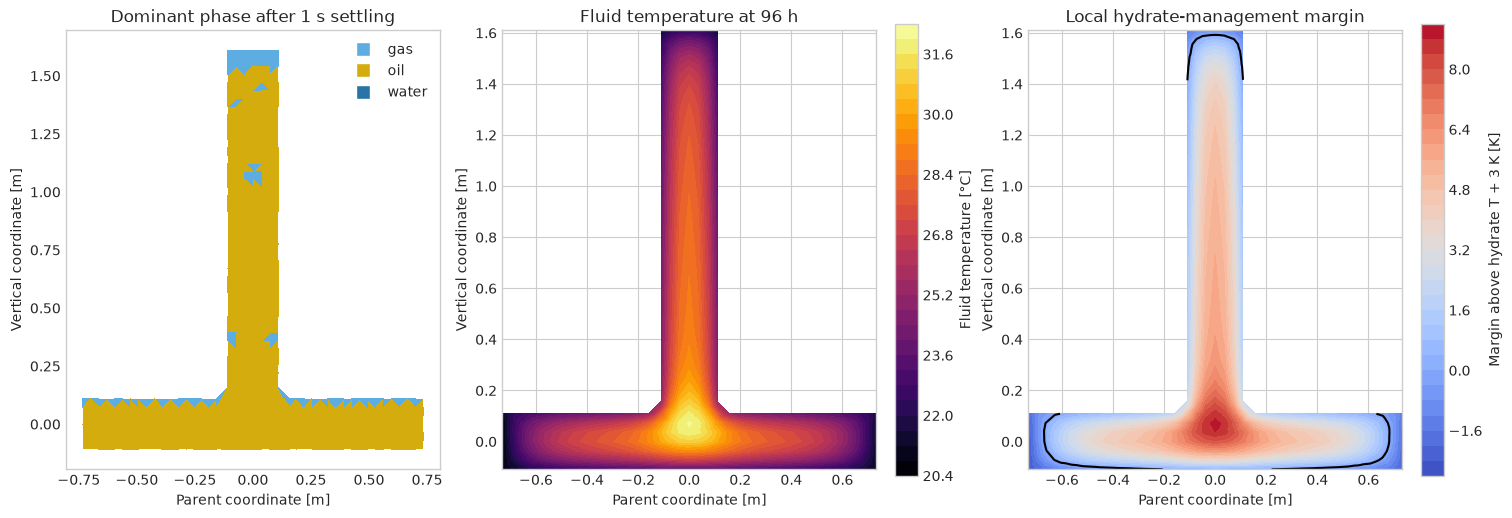

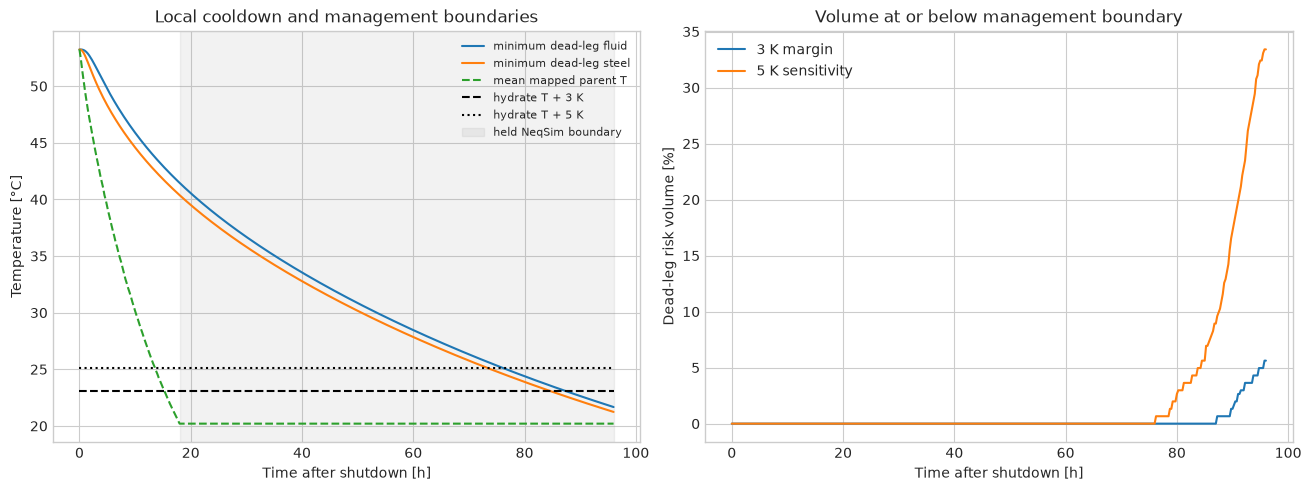

The base CFD dead leg first reaches the **3 K** boundary at **87.23 h** and the **5 K sensitivity** at **76.17 h**. Because both occur after 18 h, they depend on holding the final NeqSim boundary. The directly calculated parent-pipe limit remains **14.14 h** and therefore governs this case.

In [15]:
import matplotlib.tri as mtri
from matplotlib.colors import ListedColormap

fluid_centres = fine_cfd["centres"]["fluid"]
deadleg_mask = fine_cfd["deadleg_fluid_mask"]
alpha_matrix = np.column_stack([
    fine_cfd["settled_alpha"][phase]
    for phase in ("gas", "oil", "water")
])
dominant_phase = np.argmax(alpha_matrix, axis=1)
latest_temperature_C = fine_cfd["latest_fluid_temperature_K"] - 273.15
final_hydrate_C = fine_cfd_history.hydrate_equilibrium_C.iloc[-1]
latest_margin_3K = latest_temperature_C - final_hydrate_C - 3.0

triangulation = mtri.Triangulation(fluid_centres[:, 0], fluid_centres[:, 1])
triangle_points = fluid_centres[triangulation.triangles, :2]
maximum_edge = np.max(
    np.linalg.norm(
        triangle_points - np.roll(triangle_points, 1, axis=1), axis=2,
    ),
    axis=1,
)
triangulation.set_mask(maximum_edge > 0.09)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), constrained_layout=True)
axes[0].tripcolor(
    triangulation, dominant_phase, shading="flat",
    cmap=ListedColormap(["#5dade2", "#d4ac0d", "#2874a6"]), vmin=-0.5, vmax=2.5,
)
phase_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color, markersize=10, label=label)
    for color, label in zip(["#5dade2", "#d4ac0d", "#2874a6"], ["gas", "oil", "water"])
]
axes[0].legend(handles=phase_handles, loc="upper right")
axes[0].set_title("Dominant phase after 1 s settling")

temperature_plot = axes[1].tricontourf(
    triangulation, latest_temperature_C, levels=28, cmap="inferno",
)
fig.colorbar(temperature_plot, ax=axes[1], label="Fluid temperature [°C]")
axes[1].set_title("Fluid temperature at 96 h")

margin_plot = axes[2].tricontourf(
    triangulation, latest_margin_3K, levels=28, cmap="coolwarm",
)
axes[2].tricontour(triangulation, latest_margin_3K, levels=[0], colors="black", linewidths=1.5)
fig.colorbar(margin_plot, ax=axes[2], label="Margin above hydrate T + 3 K [K]")
axes[2].set_title("Local hydrate-management margin")
for axis in axes:
    axis.set(xlabel="Parent coordinate [m]", ylabel="Vertical coordinate [m]")
    axis.set_aspect("equal")
plt.show()

extended_boundary = boundary.groupby("time_s", as_index=False).temperature_K.mean()
extended_boundary = pd.concat([
    extended_boundary,
    pd.DataFrame({
        "time_s": [CFD_CONTROL["cfd_horizon_h"] * 3600],
        "temperature_K": [extended_boundary.temperature_K.iloc[-1]],
    }),
], ignore_index=True)
extended_hydrate = pd.concat([
    tee_history[["time_s", "hydrate_equilibrium_T_K"]],
    pd.DataFrame({
        "time_s": [CFD_CONTROL["cfd_horizon_h"] * 3600],
        "hydrate_equilibrium_T_K": [tee_history.hydrate_equilibrium_T_K.iloc[-1]],
    }),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].plot(fine_cfd_history.time_h, fine_cfd_history.minimum_deadleg_fluid_C,
             label="minimum dead-leg fluid")
axes[0].plot(fine_cfd_history.time_h, fine_cfd_history.minimum_deadleg_wall_C,
             label="minimum dead-leg steel")
axes[0].plot(extended_boundary.time_s/3600, extended_boundary.temperature_K-273.15,
             "--", label="mean mapped parent T")
axes[0].plot(extended_hydrate.time_s/3600,
             extended_hydrate.hydrate_equilibrium_T_K-273.15+3,
             "k--", label="hydrate T + 3 K")
axes[0].plot(extended_hydrate.time_s/3600,
             extended_hydrate.hydrate_equilibrium_T_K-273.15+5,
             "k:", label="hydrate T + 5 K")
axes[0].axvspan(18, 96, color="0.5", alpha=0.10, label="held NeqSim boundary")
axes[0].set(xlabel="Time after shutdown [h]", ylabel="Temperature [°C]",
            title="Local cooldown and management boundaries")
axes[0].legend(fontsize=8)

axes[1].plot(fine_cfd_history.time_h, 100*fine_cfd_history.risk_volume_fraction_3K,
             label="3 K margin")
axes[1].plot(fine_cfd_history.time_h, 100*fine_cfd_history.risk_volume_fraction_5K,
             label="5 K sensitivity")
axes[1].set(xlabel="Time after shutdown [h]", ylabel="Dead-leg risk volume [%]",
            title="Volume at or below management boundary")
axes[1].legend(); plt.show()

display(Markdown(
    f"The base CFD dead leg first reaches the **3 K** boundary at **{cfd_no_touch_3K_h:.2f} h** "
    f"and the **5 K sensitivity** at **{cfd_no_touch_5K_h:.2f} h**. "
    f"Because both occur after 18 h, they depend on holding the final NeqSim boundary. "
    f"The directly calculated parent-pipe limit remains **{no_touch_h:.2f} h** and therefore governs this case."
))

## 12. Heat-loss feedback and geometry/ambient ranking

The planar model's outer-wall heat flux is converted to an equivalent circular-pipe line loss,

$$q'_{CFD}=\left|\overline{q''}_{amb}\right|\pi D_{outer},$$

and compared with the nominal NeqSim radial-model value $q'_{1D}=U\pi D_i(T-T_a)$. The ratio is a diagnostic: local stored heat and tee surface area are embedded in the CFD result, so it should not be applied blindly as a new U-value. A candidate static tee-cell profile is exported for a controlled next NeqSim iteration.

In [16]:
comparison_time_h = 12.0
cfd_12h = fine_cfd_history.iloc[
    np.argmin(np.abs(fine_cfd_history.time_h - comparison_time_h))
]
tee_12h = tee_history.iloc[
    np.argmin(np.abs(tee_history.time_h - comparison_time_h))
]
neqsim_nominal_heat_loss_W_m = (
    radial_overall_U * math.pi * CASE["diameter_m"]
    * (float(tee_12h.temperature_C) - CASE["ambient_C"])
)
cfd_equivalent_heat_loss_W_m = float(cfd_12h.circular_equivalent_heat_loss_W_m)
heat_loss_ratio = cfd_equivalent_heat_loss_W_m / neqsim_nominal_heat_loss_W_m
heat_loss_difference_percent = 100.0 * (heat_loss_ratio - 1.0)
material_heat_loss_difference = abs(heat_loss_difference_percent) > 20.0

heat_loss_comparison = pd.DataFrame([
    ("NeqSim nominal radial model", neqsim_nominal_heat_loss_W_m, "inner-area U × πDi × ΔT"),
    ("OpenFOAM local equivalent", cfd_equivalent_heat_loss_W_m, "mean outer q'' × πDo"),
], columns=["model", "heat_loss_W_m_at_12h", "basis"])
display(heat_loss_comparison.round(4))
print(f"CFD/NeqSim heat-loss ratio at 12 h: {heat_loss_ratio:.3f}")
print(f"Material difference (>20%): {material_heat_loss_difference}")

candidate_U_profile = np.full(CASE["sections"], radial_overall_U)
candidate_U_profile[tee_cell] = radial_overall_U * heat_loss_ratio
feedback_profile = pd.DataFrame({
    "cell": np.arange(CASE["sections"]),
    "x_m": x_m,
    "baseline_U_W_m2K": radial_overall_U,
    "candidate_static_U_W_m2K": candidate_U_profile,
    "source": ["unchanged"] * CASE["sections"],
})
feedback_profile.loc[tee_cell, "source"] = "12 h CFD/1D heat-loss ratio; review before applying"
display(feedback_profile.round(4))

CFD/NeqSim heat-loss ratio at 12 h: 2.041
Material difference (>20%): True


,model,heat_loss_W_m_at_12h,basis
0,NeqSim nominal radial model,14.4259,inner-area U × πDi × ΔT
1,OpenFOAM local equivalent,29.4487,mean outer q'' × πDo


,cell,x_m,baseline_U_W_m2K,candidate_static_U_W_m2K,source
0,0,1000.0,0.7774,0.7774,unchanged
1,1,3000.0,0.7774,0.7774,unchanged
2,2,5000.0,0.7774,1.5869,12 h CFD/1D heat-loss ratio; review before app...
3,3,7000.0,0.7774,0.7774,unchanged
4,4,9000.0,0.7774,0.7774,unchanged
5,5,11000.0,0.7774,0.7774,unchanged


Reduced-model conductance calibration factor: 0.258


,case,operating_temperature_C,deadleg_length_m,inner_diameter_m,ambient_C,no_touch_3K_h,no_touch_5K_h
0,base (calibration),53.24,1.5,0.25,4.0,87.23,76.18
1,lower operating T,45.00,1.5,0.25,4.0,57.56,51.47
2,shorter dead leg,53.24,0.4,0.25,4.0,20.20,18.33
3,longer dead leg,53.24,3.0,0.25,4.0,>120,>120
4,smaller bore,53.24,1.5,0.15,4.0,67.50,59.31
5,colder ambient,53.24,1.5,0.25,0.0,82.40,72.57
6,warmer ambient,53.24,1.5,0.25,8.0,92.91,80.28
7,combined screen,45.00,3.0,0.15,0.0,81.73,73.17


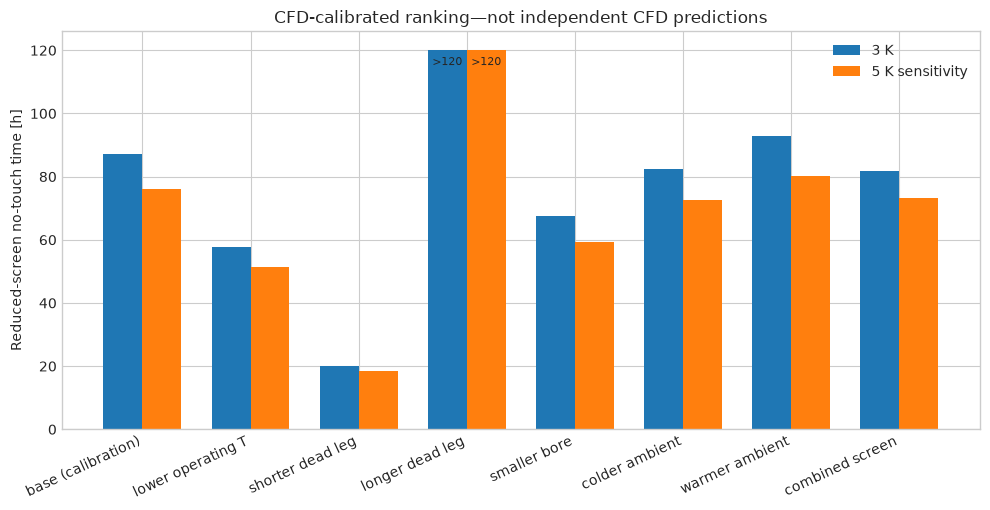

In [17]:
def reduced_deadleg_screen(
    operating_temperature_C,
    length_m,
    diameter_m,
    ambient_C,
    conductance_multiplier,
    horizon_h=120.0,
    dt_s=300.0,
    nodes=41,
):
    wall_thickness = CASE["wall_thickness_m"]
    insulation_thickness = CASE["insulation_thickness_m"]
    inner_radius = diameter_m / 2
    steel_outer_radius = inner_radius + wall_thickness
    insulation_outer_radius = steel_outer_radius + insulation_thickness
    fluid_area = math.pi * inner_radius**2
    steel_area = math.pi * (steel_outer_radius**2 - inner_radius**2)
    insulation_area = math.pi * (insulation_outer_radius**2 - steel_outer_radius**2)
    rho_mix = fine_effective["rho_effective_kg_m3"]
    cp_mix = fine_effective["cp_effective_J_kgK"]
    k_mix = fine_effective["conductivity_effective_W_mK"]
    heat_capacity_per_m = (
        rho_mix * cp_mix * fluid_area
        + 7850 * 480 * steel_area
        + 120 * 1400 * insulation_area
    )
    axial_kA_W_mK = (
        k_mix * fluid_area + 45 * steel_area + 0.035 * insulation_area
    )
    resistance_mK_W = (
        1/(CASE["closed_inner_htc_W_m2K"] * 2*math.pi*inner_radius)
        + math.log(steel_outer_radius/inner_radius)/(2*math.pi*45)
        + math.log(insulation_outer_radius/steel_outer_radius)/(2*math.pi*0.035)
        + 1/(CFD_CONTROL["external_htc_W_m2K"] * 2*math.pi*insulation_outer_radius)
    )
    ambient_conductance_W_mK = conductance_multiplier / resistance_mK_W
    dx = length_m/(nodes-1)
    diffusion = axial_kA_W_mK/dx**2
    storage = heat_capacity_per_m/dt_s
    matrix = np.zeros((nodes, nodes))
    matrix[0, 0] = 1.0
    for i in range(1, nodes-1):
        matrix[i, i-1] = -diffusion
        matrix[i, i] = storage + 2*diffusion + ambient_conductance_W_mK
        matrix[i, i+1] = -diffusion
    matrix[-1, -2] = -diffusion
    matrix[-1, -1] = storage + diffusion + ambient_conductance_W_mK

    initial_shift_K = operating_temperature_C - float(tee_initial.temperature_C)
    temperature_K = np.full(nodes, operating_temperature_C + 273.15)
    times_s = np.arange(0, horizon_h*3600 + dt_s, dt_s)
    minimum_margin_3K = []
    minimum_margin_5K = []
    for current_time_s in times_s:
        parent_temperature_K = np.interp(
            current_time_s,
            tee_history.time_s,
            tee_history.temperature_K,
        ) + initial_shift_K
        hydrate_temperature_K = np.interp(
            current_time_s,
            tee_history.time_s,
            tee_history.hydrate_equilibrium_T_K,
        )
        # The root node is the imposed parent boundary; rank the capped end of the dead leg.
        minimum_margin_3K.append(temperature_K[-1] - hydrate_temperature_K - 3)
        minimum_margin_5K.append(temperature_K[-1] - hydrate_temperature_K - 5)
        if current_time_s == times_s[-1]:
            break
        rhs = np.full(nodes, ambient_conductance_W_mK*(ambient_C+273.15))
        rhs += storage*temperature_K
        rhs[0] = parent_temperature_K
        temperature_K = np.linalg.solve(matrix, rhs)
    return {
        "no_touch_3K_h": interpolated_first_crossing(times_s/3600, minimum_margin_3K),
        "no_touch_5K_h": interpolated_first_crossing(times_s/3600, minimum_margin_5K),
    }

# Calibrate only the reduced ranking model to the base CFD 3 K crossing.
lower_factor, upper_factor = 0.05, 4.0
for _ in range(24):
    trial_factor = 0.5*(lower_factor + upper_factor)
    trial_time = reduced_deadleg_screen(
        float(tee_initial.temperature_C), CFD_GEOMETRY["deadleg_length_m"],
        CASE["diameter_m"], CASE["ambient_C"], trial_factor,
    )["no_touch_3K_h"]
    if np.isnan(trial_time) or trial_time > cfd_no_touch_3K_h:
        lower_factor = trial_factor
    else:
        upper_factor = trial_factor
screen_calibration_factor = 0.5*(lower_factor + upper_factor)

sensitivity_cases = [
    ("base (calibration)", float(tee_initial.temperature_C), 1.5, 0.254, 4.0),
    ("lower operating T", 45.0, 1.5, 0.254, 4.0),
    ("shorter dead leg", float(tee_initial.temperature_C), 0.4, 0.254, 4.0),
    ("longer dead leg", float(tee_initial.temperature_C), 3.0, 0.254, 4.0),
    ("smaller bore", float(tee_initial.temperature_C), 1.5, 0.150, 4.0),
    ("colder ambient", float(tee_initial.temperature_C), 1.5, 0.254, 0.0),
    ("warmer ambient", float(tee_initial.temperature_C), 1.5, 0.254, 8.0),
    ("combined screen", 45.0, 3.0, 0.150, 0.0),
]
sensitivity_rows = []
for name, operating_C, length_m, diameter_m, ambient_C in sensitivity_cases:
    result = reduced_deadleg_screen(
        operating_C, length_m, diameter_m, ambient_C,
        screen_calibration_factor,
    )
    sensitivity_rows.append({
        "case": name,
        "operating_temperature_C": operating_C,
        "deadleg_length_m": length_m,
        "inner_diameter_m": diameter_m,
        "ambient_C": ambient_C,
        **result,
    })
deadleg_sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity_display = deadleg_sensitivity.round(2).copy()
for column in ("no_touch_3K_h", "no_touch_5K_h"):
    sensitivity_display[column] = sensitivity_display[column].map(
        lambda value: ">120" if pd.isna(value) else f"{value:.2f}"
    )
display(sensitivity_display)

fig, ax = plt.subplots(figsize=(10, 5.2))
positions = np.arange(len(deadleg_sensitivity))
plot_3K = deadleg_sensitivity.no_touch_3K_h.fillna(120.0)
plot_5K = deadleg_sensitivity.no_touch_5K_h.fillna(120.0)
bars_3K = ax.bar(positions-0.18, plot_3K, 0.36, label="3 K")
bars_5K = ax.bar(positions+0.18, plot_5K, 0.36, label="5 K sensitivity")
for bars, source in ((bars_3K, deadleg_sensitivity.no_touch_3K_h),
                     (bars_5K, deadleg_sensitivity.no_touch_5K_h)):
    for bar, value in zip(bars, source):
        if pd.isna(value):
            ax.text(bar.get_x()+bar.get_width()/2, 118, ">120", ha="center", va="top", fontsize=8)
ax.set_xticks(positions, deadleg_sensitivity.case, rotation=25, ha="right")
ax.set(ylabel="Reduced-screen no-touch time [h]",
       title="CFD-calibrated ranking—not independent CFD predictions")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Reduced-model conductance calibration factor: {screen_calibration_factor:.3f}")

## 13. Decision and limitations

For this synthetic case, the **14.14 h parent-pipe no-touch time remains the governing answer**. The local insulated branch starts hot and reaches the 3 K threshold much later; its reported 18–96 h evolution is conditional on holding the final NeqSim boundary after the exported history ends. The CFD-calibrated one-dimensional sensitivity is a ranking tool for choosing the next full CFD cases, not a replacement for them.

Important limitations and ownership boundaries:

- NeqSim calculates the SRK-CPA phase split, properties, hydrate equilibrium, system-scale pressure/temperature/holdup histories, and parent cooldown. OpenFOAM calculates the local demonstration mesh, short gravity redistribution, frozen-phase conjugate conduction, local temperatures, and wall heat flux.
- The operator split freezes phase fractions after one second. A qualification model should run a circular 3D tee with validated natural convection, interface treatment, contact angle, phase change, and temperature-dependent properties.
- The planar rectangular slice is not a geometric substitute for a circular tee. Its heat flux is converted with a circular external perimeter only for a feedback diagnostic.
- The parent thermal boundary is calculated for 18 h and held thereafter. Extend `TwoFluidPipe` to the full CFD horizon before using the later CFD crossing in an operating decision.
- The 3 K and 5 K curves are management-margin scenarios, not hydrate formation, growth, agglomeration, deposition, plugging, restart, or inhibitor performance models.
- The reduced sensitivity model is calibrated to this CFD base case. Specialists must supply asset geometry, insulation condition, burial, marine growth, heat tracing, fluids, salinity/inhibitor data, and acceptance criteria. This notebook is educational decision support—not certified design, HAZOP, or QRA evidence.
- Track the evolving long-duration shutdown model in [equinor/neqsim#2907](https://github.com/equinor/neqsim/issues/2907) and inner-HTC ownership in [equinor/neqsim#2977](https://github.com/equinor/neqsim/issues/2977).

In [18]:
fine_cfd_history.to_csv(handoff_dir / "openfoam_deadleg_cooldown.csv", index=False)
cfd_checks.to_csv(handoff_dir / "openfoam_verification.csv", index=False)
feedback_profile.to_csv(handoff_dir / "neqsim_candidate_U_profile.csv", index=False)
deadleg_sensitivity.to_csv(handoff_dir / "deadleg_sensitivity_screen.csv", index=False)

cfd_manifest = {
    "schema_version": 2,
    "openfoam_build": openfoam_build,
    "model": "2D planar operator-split multiphase settling plus three-region conjugate conduction",
    "geometry": CFD_GEOMETRY,
    "control": CFD_CONTROL,
    "direct_neqsim_history_h": CASE["horizon_h"],
    "held_boundary_extension_h": CFD_CONTROL["cfd_horizon_h"] - CASE["horizon_h"],
    "fine_cell_counts": fine_cfd["cell_counts"],
    "phase_volume_drift": fine_cfd["phase_volume_drift"],
    "thermal_energy_relative_residual": fine_cfd["energy_residual"],
    "parent_pipe_no_touch_3K_h": no_touch_h,
    "deadleg_no_touch_3K_h": cfd_no_touch_3K_h,
    "deadleg_no_touch_5K_h": cfd_no_touch_5K_h,
    "heat_loss_ratio_at_12h": heat_loss_ratio,
    "governing_limit": "parent pipe",
}
(handoff_dir / "openfoam_manifest.json").write_text(
    json.dumps(cfd_manifest, indent=2), encoding="utf-8",
)

cfd_case_archive = Path(
    shutil.make_archive(
        str(runtime_parent / "openfoam_deadleg_fine_case"),
        "zip",
        root_dir=fine_case,
    )
)
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(handoff_dir.iterdir()):
        archive.write(path, arcname=path.name)

result_summary = {
    "neqsim_commit": source_commit,
    "steady_runtime_s": steady_elapsed_s,
    "fine_shutdown_runtime_s": fine_elapsed_s,
    "coarse_shutdown_runtime_s": coarse_elapsed_s,
    "fine_no_touch_time_h": no_touch_h,
    "coarse_no_touch_time_h": coarse_no_touch_h,
    "time_step_difference_percent": dt_difference_percent,
    "lumped_no_touch_time_h": lumped_no_touch_h,
    "critical_cell": critical_cell,
    "critical_position_km": float(critical_row.x_m / 1000.0),
    "radial_overall_U_W_m2K_inner_basis": radial_overall_U,
    "max_relative_mass_drift": mass_drift,
    "max_mass_balance_relative_residual": mass_residual,
    "max_thermal_energy_relative_residual": energy_residual,
    "handoff_zip": str(zip_path),
}
result_summary.update({
    "openfoam_build": openfoam_build,
    "openfoam_runtime_s": cfd_execution_s,
    "openfoam_postprocess_s": cfd_postprocess_s,
    "openfoam_fine_fluid_cells": fine_cfd["cell_counts"]["fluid"],
    "openfoam_phase_volume_max_drift": maximum_phase_volume_drift,
    "openfoam_energy_relative_residual": fine_cfd["energy_residual"],
    "openfoam_deadleg_no_touch_3K_h": cfd_no_touch_3K_h,
    "openfoam_deadleg_no_touch_5K_h": cfd_no_touch_5K_h,
    "openfoam_heat_loss_ratio_at_12h": heat_loss_ratio,
    "governing_no_touch_time_h": no_touch_h,
    "governing_location": "NeqSim parent pipe",
    "openfoam_case_archive": str(cfd_case_archive),
})
print(json.dumps(result_summary, indent=2))
print(f"Updated handoff: {zip_path} ({zip_path.stat().st_size:,} bytes)")
print(f"Reusable fine OpenFOAM case: {cfd_case_archive} ({cfd_case_archive.stat().st_size:,} bytes)")
assert zip_path.stat().st_size > 10_000
assert cfd_case_archive.stat().st_size > 100_000
print("PASS — NeqSim cooldown, executable OpenFOAM dead-leg screening, verification, and feedback complete")

{
  "neqsim_commit": "879eeded80135ad485de4327907fe6c3282cba08",
  "steady_runtime_s": 1.957504529000289,
  "fine_shutdown_runtime_s": 9.507636828000614,
  "coarse_shutdown_runtime_s": 8.776451232999534,
  "fine_no_touch_time_h": 14.139156799240137,
  "coarse_no_touch_time_h": 14.150221841944923,
  "time_step_difference_percent": 0.07825815118890588,
  "lumped_no_touch_time_h": 59.69513036057004,
  "critical_cell": 0,
  "critical_position_km": 1.0,
  "radial_overall_U_W_m2K_inner_basis": 0.7773780807850504,
  "max_relative_mass_drift": 3.0658144456950823e-15,
  "max_mass_balance_relative_residual": 1.1996665222285128e-15,
  "max_thermal_energy_relative_residual": 1.2379960801483927e-12,
  "handoff_zip": "/tmp/openfoam_deadleg_handoff.zip",
  "openfoam_build": "14-7b05503f98a8",
  "openfoam_runtime_s": 27.958511189999626,
  "openfoam_postprocess_s": 12.239455599999928,
  "openfoam_fine_fluid_cells": 623,
  "openfoam_phase_volume_max_drift": 5.687495487710546e-07,
  "openfoam_energy_rela